In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install pyclustering

In [ ]:
 pip install catboost

In [ ]:
pip install optuna

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_score, GridSearchCV
import warnings
import lightgbm as lgb
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error as MSE
from google.colab import files
import pandas as pd
import geocoder
import os
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from pyclustering.cluster.xmeans import xmeans, kmeans_plusplus_initializer
from pyclustering.utils import draw_clusters
from sklearn import datasets, preprocessing
from pyclustering.cluster.xmeans import xmeans
from pyclustering.cluster.center_initializer import kmeans_plusplus_initializer
from catboost import Pool, CatBoostRegressor
from catboost.datasets import rotten_tomatoes
import xgboost as xgb
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error as MSE
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
import optuna.integration.lightgbm as oplgb # lgb → oplgb
import sklearn.metrics
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import Ridge
from yellowbrick.regressor import AlphaSelection
from keras.layers import Dense, Dropout
from keras.models import Sequential
from sklearn.metrics import log_loss
from keras.callbacks import EarlyStopping

ModuleNotFoundError: No module named 'pyclustering'

In [1]:
df = pd.read_csv('drive/My Drive/Colab Notebooks/国勢/train.csv')
df['test'] = 0
df['Income_log'] = np.log(df['Income']+1)
df['Men_rate'] = df['Men']/df['TotalPop']
df['S&C'] = df['State'].str.cat(df['County'])
df['GenderRatio'] = df['Men'] / df['Women']
df['EmploymentRate'] = df['Employed'] / df['TotalPop']
df['PrivateWorkRatio'] = df['PrivateWork'] / df['PublicWork']
df['PrivateWorkRatio'] = df['PrivateWorkRatio'].apply( lambda x: 10000 if x==float('inf') else x )
df['CitizenRatio'] = df['Citizen'] / df['TotalPop']
df['Employment_num'] = df['TotalPop'] - df['Unemployment']
#df['MeanCommute_Citizen'] = df['MeanCommute'] * df['CitizenRatio']
#df['MeanCommute_Office'] = df['MeanCommute'] * df['Office']
#df['MeanCommute_Professional'] = df['MeanCommute'] * df['Professional']
df['CP'] = 0
df['CP']=df['CP'].where(df['ChildPoverty']==None,1)
df['MC'] = 0
df['MC']=df['MC'].where(df['MeanCommute']==None,1)
print(df.isnull().sum())
print(df.info())
df.head()

NameError: name 'pd' is not defined

In [ ]:
test = pd.read_csv('drive/My Drive/Colab Notebooks/国勢/test.csv')
test['Income'] = 0
test['test'] = 1
test['Income_log'] = np.log(test['Income']+1)
test['Men_rate'] = test['Men']/test['TotalPop']
test['S&C'] = test['State'].str.cat(test['County'])
test['GenderRatio'] = test['Men'] / test['Women']
test['EmploymentRate'] = test['Employed'] / test['TotalPop']
test['PrivateWorkRatio'] = test['PrivateWork'] / test['PublicWork']
test['PrivateWorkRatio'] = test['PrivateWorkRatio'].apply( lambda x: 10000 if x==float('inf') else x )
test['CitizenRatio'] = test['Citizen'] / test['TotalPop']
test['Employment_num'] = test['TotalPop'] - test['Unemployment']
#test['MeanCommute_Citizen'] = test['MeanCommute'] * test['CitizenRatio']
#test['MeanCommute_Office'] = test['MeanCommute'] * test['Office']
#test['MeanCommute_Professional'] = test['MeanCommute'] * test['Professional']
test['CP'] = 0
test['CP']=test['CP'].where(test['ChildPoverty']==None,1)
test['MC'] = 0
test['MC']=test['MC'].where(test['MeanCommute']==None,1)
print(test.isnull().sum())
print(test.info())
test.head()

id                   0
State                0
County               0
TotalPop             0
Men                  0
Women                0
Hispanic             0
White                0
Black                0
Native               0
Asian                0
Pacific              0
Citizen              0
Poverty              0
ChildPoverty        54
Professional         0
Service              0
Office               0
Construction         0
Production           0
Drive                0
Carpool              0
Transit              0
Walk                 0
OtherTransp          0
WorkAtHome           0
MeanCommute          7
Employed             0
PrivateWork          0
PublicWork           0
SelfEmployed         0
FamilyWork           0
Unemployment         0
Income               0
test                 0
Income_log           0
Men_rate             0
S&C                  0
GenderRatio          0
EmploymentRate       0
PrivateWorkRatio     0
CitizenRatio         0
Employment_num       0
CP         

,id,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,Income_log,Men_rate,S&C,GenderRatio,EmploymentRate,PrivateWorkRatio,CitizenRatio,Employment_num,CP,MC
0,test_00000,Wisconsin,Green Lake,2667,1407,1260,2.8,91.6,2.7,0.2,...,0.0,0.527559,WisconsinGreen Lake,1.116667,0.515561,6.652174,0.810649,2662.8,1,1
1,test_00001,Arkansas,Pulaski,3247,1546,1701,8.1,63.2,23.4,0.0,...,0.0,0.476132,ArkansasPulaski,0.908877,0.510317,2.870079,0.658146,3242.1,1,1
2,test_00002,New Jersey,Union,3930,1913,2017,14.1,82.5,0.8,0.0,...,0.0,0.486768,New JerseyUnion,0.948438,0.509160,2.925926,0.770738,3920.5,1,1
3,test_00003,New York,Wayne,4226,2000,2226,3.1,86.2,7.4,0.1,...,0.0,0.473261,New YorkWayne,0.898473,0.445812,3.708543,0.758637,4219.1,1,1
4,test_00004,Texas,Grayson,4622,2476,2146,8.8,84.9,0.2,1.8,...,0.0,0.535699,TexasGrayson,1.153774,0.487451,6.023256,0.749459,4618.0,1,1


In [ ]:
'''
# 実行に30分程度かかるため、注意!!!
read_opts = {
    'encoding': 'utf-8',
    'index_col': 0
}

# 緯度経度の情報を取得・追加する（フォーラムより）
def get_latlng(addr: str) -> [float, float]:
    latlng = None
    while not latlng:
        ret = geocoder.osm(addr)
        addr = addr[:-1]
        latlng = ret.latlng
    return latlng

df_latling1 = df[['State', 'County']].drop_duplicates()
df_latling2 = test[['State', 'County']].drop_duplicates()
df_latling = pd.concat([df_latling1, df_latling2], axis=0, ignore_index=False)
df_latling = df_latling.drop_duplicates()
df_latling.info()
df_latling.head()

df_latling["latlng"] = df_latling.apply(lambda row: get_latlng(f"{row['County']}, {row['State']}"), axis=1)
df_latling.head()
print(df_latling.isnull().sum())
'''

'\n# 実行に30分程度かかるため、注意!!!\nread_opts = {\n    \'encoding\': \'utf-8\',\n    \'index_col\': 0\n}\n\n# 緯度経度の情報を取得・追加する（フォーラムより）\ndef get_latlng(addr: str) -> [float, float]:\n    latlng = None\n    while not latlng:\n        ret = geocoder.osm(addr)\n        addr = addr[:-1]\n        latlng = ret.latlng\n    return latlng\n\ndf_latling1 = df[[\'State\', \'County\']].drop_duplicates()\ndf_latling2 = test[[\'State\', \'County\']].drop_duplicates()\ndf_latling = pd.concat([df_latling1, df_latling2], axis=0, ignore_index=False)\ndf_latling = df_latling.drop_duplicates()\ndf_latling.info()\ndf_latling.head()\n\ndf_latling["latlng"] = df_latling.apply(lambda row: get_latlng(f"{row[\'County\']}, {row[\'State\']}"), axis=1)\ndf_latling.head()\nprint(df_latling.isnull().sum())\n'

In [ ]:
# 上記コードは実行に30分程度かかるため、結果を出力
# df_latling.to_csv('drive/My Drive/Colab Notebooks/国勢/latling.csv', index=False)

In [ ]:
# 上記出力したcsvの取り込み
df_latling = pd.read_csv('drive/My Drive/Colab Notebooks/国勢/latling.csv')
df_latling['S&C'] = df_latling['State'].str.cat(df_latling['County'])
df_latling = df_latling.drop(['State'], axis=1)
df_latling = df_latling.drop(['County'], axis=1)

df_latling["Latitude"] =  df_latling["latlng"].apply(lambda x: x[1:x.find(',')]) #緯度
df_latling["Longitude"] = df_latling["latlng"].apply(lambda x: x[x.find(',')+1:x.find(']')]) #経度
df_latling["Latitude"] = df_latling["Latitude"].astype(float, errors="raise")
df_latling["Longitude"] = df_latling["Longitude"].astype(float, errors="raise")
df_latling["Longitude"].head()

df = pd.merge(df, df_latling, on='S&C')
test = pd.merge(test, df_latling, on='S&C')

In [ ]:
# CountyのGDPを追加する（フォーラムより。アメリカ経済分析局 --U.S. Bureau of Economic Analysis (BEA):https://www.bea.gov/sites/default/files/2018-12/GCP_Release_1.xlsx
# Abbreviationもフォーラム情報を参照:https://github.com/jasonong/List-of-US-States/blob/master/states.csv
df_state = pd.read_csv('drive/My Drive/Colab Notebooks/国勢/【作業】GDP_CountyUSA3.csv')
df_state["GDP_all"] = df_state["GDP2014_comp"][(df_state['LineCode'] == 1.0)]
df_state["GDP_good"] = df_state["GDP2014_comp"][(df_state['LineCode'] == 2.0)]
df_state["GDP_service"] = df_state["GDP2014_comp"][(df_state['LineCode'] == 3.0)]
df_state["GDP_gov"] = df_state["GDP2014_comp"][(df_state['LineCode'] == 4.0)]
df_state = df_state.drop(['State Code (FIPS)','Postal','LineCode','IndustryName','GDP2012','GDP2013','GDP2014','GDP2014_comp'], axis=1)
df_state = df_state.groupby(['State','County','FIPS'], as_index=False).sum()
print(df_state.info())
df_state.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3142 entries, 0 to 3141
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   State        3142 non-null   object 
 1   County       3142 non-null   object 
 2   FIPS         3142 non-null   float64
 3   GDP_all      3142 non-null   float64
 4   GDP_good     3142 non-null   float64
 5   GDP_service  3142 non-null   float64
 6   GDP_gov      3142 non-null   float64
dtypes: float64(5), object(2)
memory usage: 172.0+ KB
None


,State,County,FIPS,GDP_all,GDP_good,GDP_service,GDP_gov
0,Alabama,Autauga,1001.0,1402516.0,323582.0,928438.0,150496.0
1,Alabama,Baldwin,1003.0,6547396.0,711443.0,5194273.0,641681.0
2,Alabama,Barbour,1005.0,689212.0,286467.0,291688.0,111057.0
3,Alabama,Bibb,1007.0,329087.0,108170.0,138327.0,82591.0
4,Alabama,Blount,1009.0,688525.0,206791.0,347601.0,134133.0


In [ ]:
# Countyの不動産情報を追加する（フォーラムより。Housing Data - Zillow Research:https://files.zillowstatic.com/research/public_csvs/zhvi/County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv?t=1700053200
df_state3 = pd.read_csv('drive/My Drive/Colab Notebooks/国勢/【作業】County_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv')
df_state3 = df_state3.drop(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State_code', 'StateCodeFIPS', 'MunicipalCodeFIPS', 'StateCodeFIPS.1', 'MunicipalCodeFIPS.1',
                             '2000/12/31','2001/12/31', '2002/12/31', '2003/12/31', '2004/12/31','2005/12/31', '2006/12/31', '2007/12/31', '2008/12/31', '2009/12/31', '2010/12/31', '2011/12/31', '2015/12/31'], axis=1)
print(df_state3.info())
df_state3.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3074 entries, 0 to 3073
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Metro       1831 non-null   object 
 1   FIPS        3074 non-null   int64  
 2   2012/12/31  2426 non-null   float64
 3   2013/12/31  2477 non-null   float64
 4   2014/12/31  2514 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 120.2+ KB
None


,Metro,FIPS,2012/12/31,2013/12/31,2014/12/31
0,"Los Angeles-Long Beach-Anaheim, CA",6037,363049.5473,430119.0674,466313.5530
1,"Chicago-Naperville-Elgin, IL-IN-WI",17031,154705.9392,175476.9112,189833.9630
2,"Houston-The Woodlands-Sugar Land, TX",48201,123849.7695,136960.9617,153149.8360
3,"Phoenix-Mesa-Chandler, AZ",4013,167762.7378,201173.2964,210490.4284
4,"San Diego-Chula Vista-Carlsbad, CA",6073,358545.6122,425487.9938,453597.2613


In [ ]:
df_state = pd.merge(df_state, df_state3, on='FIPS', how="left")
print(df_state.isnull().sum())
print(df_state.info())
df_state.head()

df = pd.merge(df, df_state, on=['State','County'], how="left")
test = pd.merge(test, df_state, on=['State','County'],  how="left")
print(df.isnull().sum())
print(df.info())
print(test.isnull().sum())
print(test.info())

State             0
County            0
FIPS              0
GDP_all           0
GDP_good          0
GDP_service       0
GDP_gov           0
Metro          1354
2012/12/31      761
2013/12/31      712
2014/12/31      676
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 3142 entries, 0 to 3141
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   State        3142 non-null   object 
 1   County       3142 non-null   object 
 2   FIPS         3142 non-null   float64
 3   GDP_all      3142 non-null   float64
 4   GDP_good     3142 non-null   float64
 5   GDP_service  3142 non-null   float64
 6   GDP_gov      3142 non-null   float64
 7   Metro        1788 non-null   object 
 8   2012/12/31   2381 non-null   float64
 9   2013/12/31   2430 non-null   float64
 10  2014/12/31   2466 non-null   float64
dtypes: float64(8), object(3)
memory usage: 294.6+ KB
None
id                     0
State                  0
Count

In [ ]:
# Countyの教育情報を追加する（フォーラムより。https://www.ers.usda.gov/data-products/county-level-data-sets/county-level-data-sets-download-data/ https://www.ers.usda.gov/webdocs/DataFiles/48747/Education.xlsx?v=5130.9
# csvは数字を数値型に変更すること
df_edu = pd.read_csv('drive/My Drive/Colab Notebooks/国勢/【作業】Education.csv')
print(df_edu.info())
df_edu.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3285 entries, 0 to 3284
Data columns (total 7 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Federal Information Processing Standard (FIPS) Code  3285 non-null   int64  
 1   State                                                3167 non-null   object 
 2   County                                               3167 non-null   object 
 3   LessThanHighSchoolDiploma_2008-12                    3274 non-null   float64
 4   BachelorDegreeOrHigher_2008-12                       3274 non-null   float64
 5   PercentAdultsLessThanHighSchoolDiploma_2008-12       3274 non-null   float64
 6   PercentAdultsBachelorDegreeOrHigher_2008-12          3274 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 179.8+ KB
None


,Federal Information Processing Standard (FIPS) Code,State,County,LessThanHighSchoolDiploma_2008-12,BachelorDegreeOrHigher_2008-12,PercentAdultsLessThanHighSchoolDiploma_2008-12,PercentAdultsBachelorDegreeOrHigher_2008-12
0,0,NaN,NaN,29179819.0,58205022.0,14.3,28.5
1,1000,NaN,NaN,551030.0,705001.0,17.4,22.3
2,1001,Alabama,Autauga,5232.0,7629.0,14.9,21.7
3,1003,Alabama,Baldwin,14792.0,35307.0,11.6,27.7
4,1005,Alabama,Barbour,5013.0,2757.0,26.4,14.5


In [ ]:
df = pd.merge(df, df_edu, on=['State','County'], how="left")
test = pd.merge(test, df_edu, on=['State','County'],  how="left")
print(df.isnull().sum())
print(df.info())
print(test.isnull().sum())
print(test.info())

id                                                       0
State                                                    0
County                                                   0
TotalPop                                                 0
Men                                                      0
                                                      ... 
Federal Information Processing Standard (FIPS) Code    695
LessThanHighSchoolDiploma_2008-12                      695
BachelorDegreeOrHigher_2008-12                         695
PercentAdultsLessThanHighSchoolDiploma_2008-12         695
PercentAdultsBachelorDegreeOrHigher_2008-12            695
Length: 62, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 51030 entries, 0 to 51029
Data columns (total 62 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   id                                              

In [ ]:
# CountyのTax情報を追加する（フォーラムより。https://www.irs.gov/pub/irs-soi/14incyallnoagi.csv
# 変数はIncomeとの相関係数が高かった上位５つを採用
df_tax = pd.read_csv('drive/My Drive/Colab Notebooks/国勢/【作業】14incyallnoagi.csv')
df_tax = df_tax.drop(['STATE','COUNTYNAME'], axis=1)
df_tax = df_tax[['FIPS','N85530','N85300','N09600','A18500','N07300']]

print(df_tax.info())
df_tax.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   FIPS    3192 non-null   int64
 1   N85530  3192 non-null   int64
 2   N85300  3192 non-null   int64
 3   N09600  3192 non-null   int64
 4   A18500  3192 non-null   int64
 5   N07300  3192 non-null   int64
dtypes: int64(6)
memory usage: 149.8 KB
None


,FIPS,N85530,N85300,N09600,A18500,N07300
0,1000,21810,28130,21240,598983,63560
1,1001,110,150,100,4049,640
2,1003,1240,1630,1310,27465,4330
3,1005,30,50,40,1499,200
4,1007,0,30,30,725,80


In [ ]:
df = pd.merge(df, df_tax, on=['FIPS'], how="left")
test = pd.merge(test, df_tax, on=['FIPS'],  how="left")
print(df.isnull().sum())
print(df.info())
print(test.isnull().sum())
print(test.info())

id             0
State          0
County         0
TotalPop       0
Men            0
            ... 
N85530      1169
N85300      1169
N09600      1169
A18500      1169
N07300      1169
Length: 67, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 51030 entries, 0 to 51029
Data columns (total 67 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   id                                                   51030 non-null  object 
 1   State                                                51030 non-null  object 
 2   County                                               51030 non-null  object 
 3   TotalPop                                             51030 non-null  int64  
 4   Men                                                  51030 non-null  int64  
 5   Women                                                51030 non-null  int64  
 6   Hispanic          

In [ ]:
#フォーラムより。世界各国の主要都市の緯度経度のリスト:https://on-ze.com/wordpress/wp-content/uploads/2015/01/city_list.txt
df_city = pd.read_csv('drive/My Drive/Colab Notebooks/国勢/city_list.csv')
print(df_city.info())
df_city.head()

#Puerto RicoのAbbreviation（略語：PR）: https://en.wikipedia.org/wiki/Puerto_Rico
df_city = df_city.query('countryCode == "US" or countryCode == "PR"')
print(df_city.info())
df_city.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74071 entries, 0 to 74070
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           74071 non-null  int64  
 1   nm           74067 non-null  object 
 2   lat          74071 non-null  float64
 3   lon          74071 non-null  float64
 4   countryCode  74035 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 2.8+ MB
None
<class 'pandas.core.frame.DataFrame'>
Int64Index: 11879 entries, 666 to 73873
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11879 non-null  int64  
 1   nm           11879 non-null  object 
 2   lat          11879 non-null  float64
 3   lon          11879 non-null  float64
 4   countryCode  11879 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 556.8+ KB
None


,id,nm,lat,lon,countryCode
666,7262440,Valencia West,32.132381,-111.114143,US
667,5495380,Tularosa,33.073971,-106.018600,US
740,5301442,Lake of the Woods,34.163929,-109.989548,US
743,4190542,Dahlonega,34.532589,-83.984909,US
745,5322400,Adelanto,34.582771,-117.409218,US


In [ ]:
#参考Pythonコード https://qiita.com/sakabe/items/470b7c72c535de477f7c

# 後工程でデータを分けるために使用
df["tmp"] = "train"
test["tmp"] = "test"

#　変数を生成するために一時的にtrainとtestを結合
conb = pd.concat([df[['Latitude', 'Longitude', 'tmp']], test[['Latitude', 'Longitude', 'tmp']]])

# データ処理のためにpandasからnp.arrayに変換
conb_array = np.array(conb[conb.columns[0]].tolist()) # conb.columns[0] → 'Latitude'

for i in range(len(conb.columns)):
    if i <= 0:
        continue
    if conb.columns[i]=="tmp":
        continue
    conb_array = np.vstack((conb_array,conb[conb.columns[i]])) # vstackでconb.columns[1]('Longitude')を追加
conb_array = conb_array.T

print(conb_array)

# X-meansによるクラスタ数の計算
amount_initial_centers = 10 # 最小～クラス以上に分類する
initial_centers = kmeans_plusplus_initializer(conb_array, amount_initial_centers).initialize()
instances = xmeans(conb_array, initial_centers, ccore=True)
instances.process()
clusters = instances.get_clusters()

# 各クラスタの中心の数を求める
centers = []
conb_array = np.array(conb_array)
for cluster in clusters:
    c = conb_array[cluster, :]
    centers.append(np.mean(c, axis=0))

cluster_point = len(centers)
pred = KMeans(n_clusters=cluster_point).fit_predict(conb_array)
conb["cluster"] = pred

# trainとtestに再分割
df["cluster"] = conb[conb["tmp"]=="train"]["cluster"]
test["cluster"] = conb[conb["tmp"]=="test"]["cluster"]
df.drop("tmp",axis=1,inplace=True)
test.drop("tmp",axis=1,inplace=True)

df.head()

[[ 28.7225829 -81.2353683]
 [ 28.7225829 -81.2353683]
 [ 28.7225829 -81.2353683]
 ...
 [ 47.7113958 -98.9087265]
 [ 48.0513335 -96.0829271]
 [ 44.0129518 -97.6043451]]


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,id,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,LessThanHighSchoolDiploma_2008-12,BachelorDegreeOrHigher_2008-12,PercentAdultsLessThanHighSchoolDiploma_2008-12,PercentAdultsBachelorDegreeOrHigher_2008-12,N85530,N85300,N09600,A18500,N07300,cluster
0,train_00000,Florida,Seminole,4157,2041,2116,15.6,64.7,10.8,0.2,...,24670.0,95691.0,8.7,33.6,4050.0,4420.0,2980.0,155210.0,10370.0,6
1,train_00976,Florida,Seminole,4947,2633,2314,20.9,58.7,14.4,0.0,...,24670.0,95691.0,8.7,33.6,4050.0,4420.0,2980.0,155210.0,10370.0,6
2,train_01679,Florida,Seminole,4319,2352,1967,8.0,71.8,10.4,0.0,...,24670.0,95691.0,8.7,33.6,4050.0,4420.0,2980.0,155210.0,10370.0,6
3,train_05135,Florida,Seminole,6638,3347,3291,30.9,46.7,20.4,0.0,...,24670.0,95691.0,8.7,33.6,4050.0,4420.0,2980.0,155210.0,10370.0,6
4,train_05345,Florida,Seminole,6479,3176,3303,26.7,59.9,9.3,1.3,...,24670.0,95691.0,8.7,33.6,4050.0,4420.0,2980.0,155210.0,10370.0,6


In [ ]:
df_map1 = df_latling[["Longitude", "Latitude"]]
df_map1["flg"] = 100000
df_map2 = pd.DataFrame()
df_map2["Longitude"] = round(df_city["lon"],1) #小数点以下２桁を四捨五入
df_map2["Latitude"] = round(df_city["lat"],1)
df_map2["flg"] = 50000
df_map2 = df_map2.drop_duplicates()
df_map = pd.concat([df_map1, df_map2], ignore_index=True)
print(df_map.info())
df_map.head()

df_map['Longitude_1'] = round(df_map['Longitude'], 1)#小数点以下２桁を四捨五入
df_map['Latitude_1'] = round(df_map['Latitude'], 1)
df_map.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11140 entries, 0 to 11139
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Longitude  11140 non-null  float64
 1   Latitude   11140 non-null  float64
 2   flg        11140 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 261.2 KB
None


<ipython-input-114-1417db92a702>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_map1["flg"] = 100000


,Longitude,Latitude,flg,Longitude_1,Latitude_1
0,-81.235368,28.722583,100000,-81.2,28.7
1,-121.387742,36.223108,100000,-121.4,36.2
2,-76.241128,40.080670,100000,-76.2,40.1
3,-89.810796,38.047292,100000,-89.8,38.0
4,-88.237089,43.373499,100000,-88.2,43.4


<ipython-input-115-16bf5926c5a1>:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('YlGnBu')


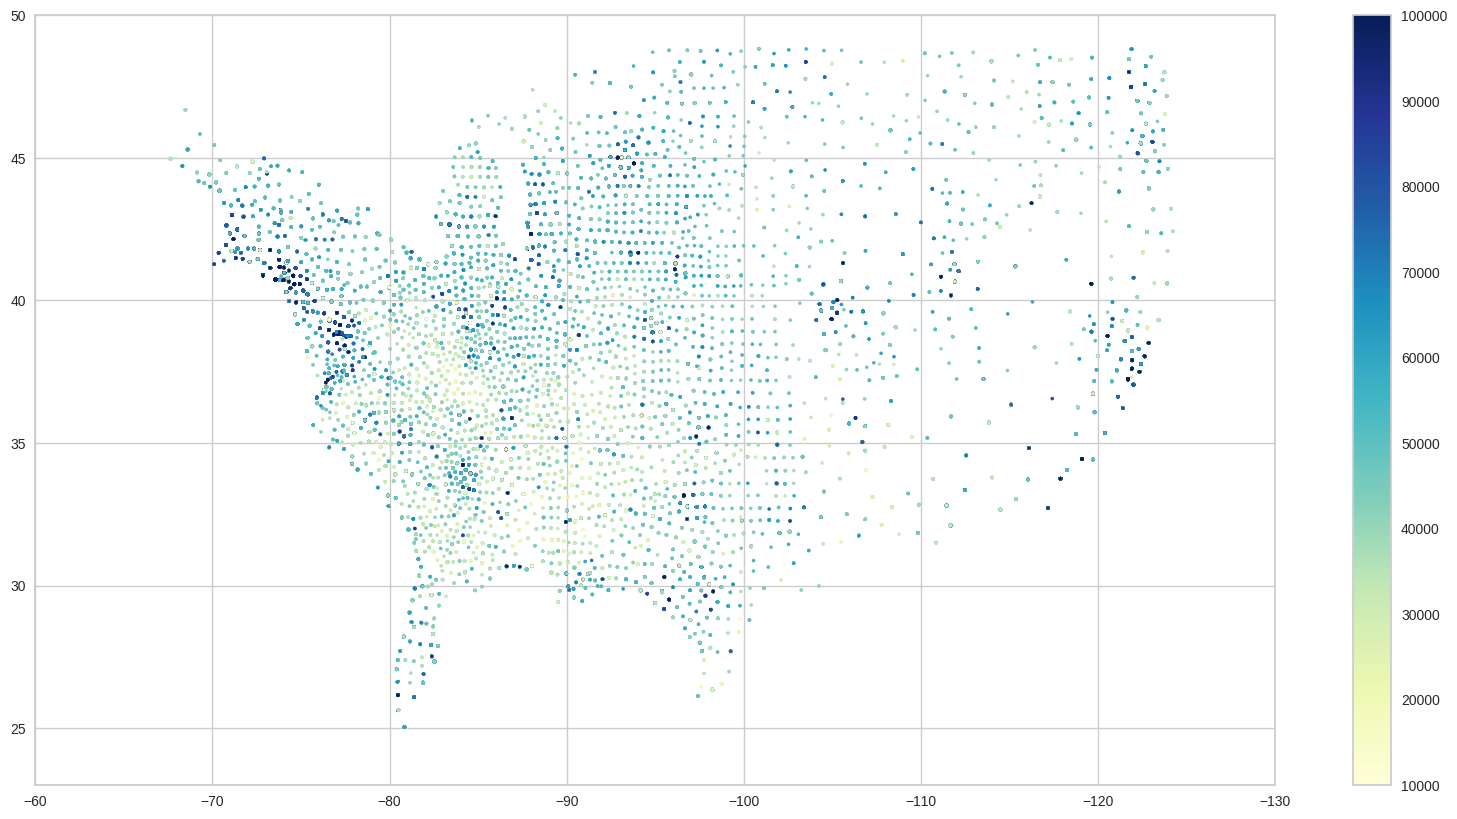

In [ ]:
plt.figure(figsize=(20,10))
cm = plt.cm.get_cmap('YlGnBu')
sc = plt.scatter(df['Longitude'],df['Latitude'], vmin=10000, vmax=100000, c=df['Income'], cmap=cm, s=5, marker="o")
plt.colorbar(sc)
plt.ylim(23,50)
plt.xlim(-60,-130)
plt.show()

<ipython-input-116-55957b1257f3>:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('YlGnBu')


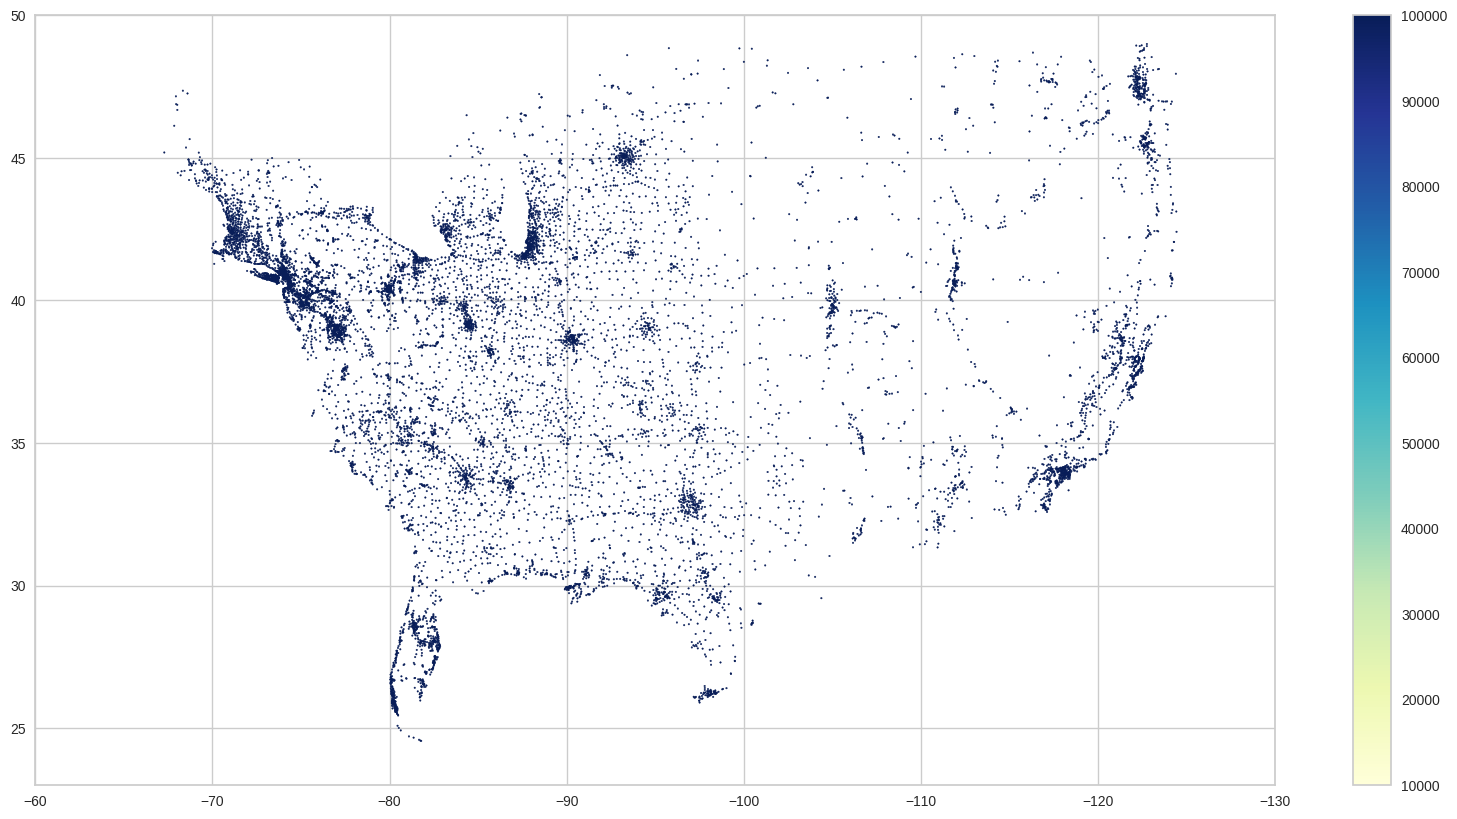

In [ ]:
plt.figure(figsize=(20,10))
cm = plt.cm.get_cmap('YlGnBu')
sc = plt.scatter(df_city['lon'],df_city['lat'], vmin=10000, vmax=100000, c=df_city['id'], cmap=cm, s=5, marker=".")
plt.colorbar(sc)
plt.ylim(23,50)
plt.xlim(-60,-130)
plt.show()

<ipython-input-117-7e45866cd013>:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('YlGnBu')


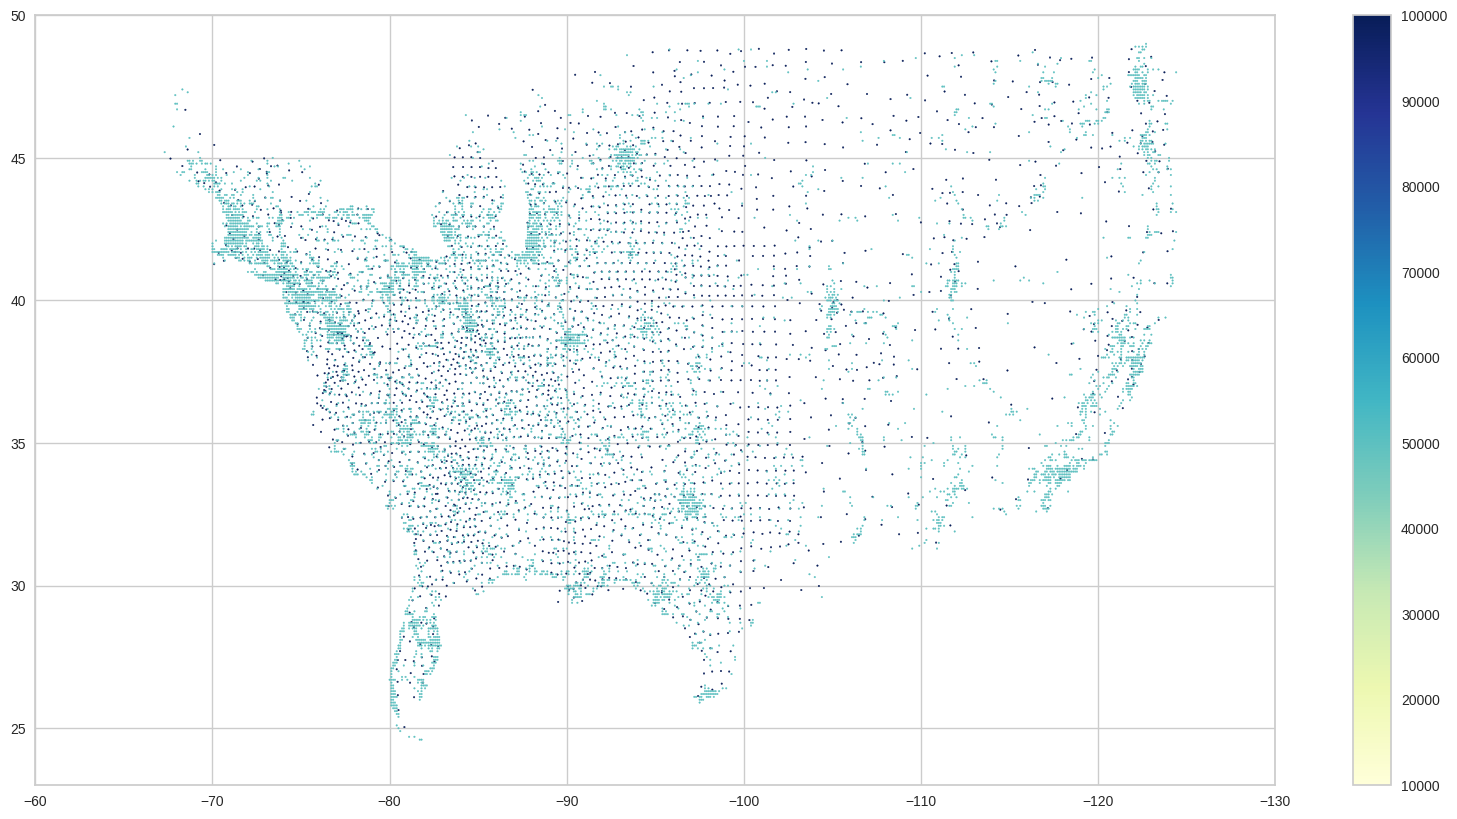

In [ ]:
plt.figure(figsize=(20,10))
cm = plt.cm.get_cmap('YlGnBu')
sc = plt.scatter(df_map['Longitude'],df_map['Latitude'], vmin=10000, vmax=100000, c=df_map['flg'], cmap=cm, s=5, marker=".")
plt.colorbar(sc)
plt.ylim(23,50)
plt.xlim(-60,-130)
plt.show()

<ipython-input-118-b18d83238f00>:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('YlGnBu')


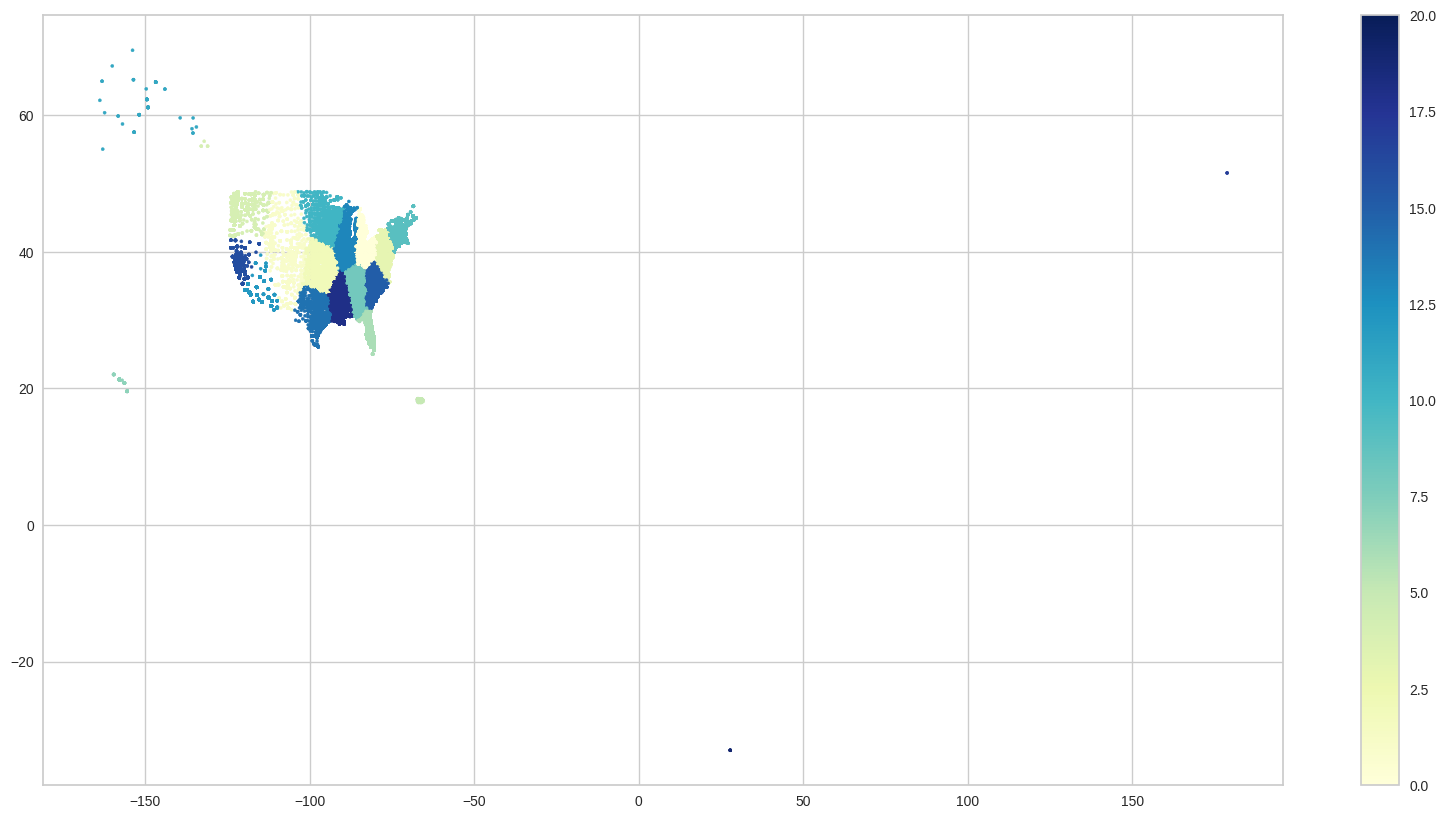

In [ ]:
plt.figure(figsize=(20,10))
cm = plt.cm.get_cmap('YlGnBu')
sc = plt.scatter(df['Longitude'],df['Latitude'], vmin=0, vmax=20, c=df['cluster'], cmap=cm, s=5, marker="o")
plt.colorbar(sc)
#plt.ylim(23,50)
#plt.xlim(-60,-130)
plt.show()

In [ ]:
#DataFrameを一行づつ読み込みして、元データと大都市の緯度経度で紐付け＆カウント
df_map['Count'] = 0
i = 0

for index, row in df_map.iterrows():
  if row[2]==100000:
    df_map.iloc[i,5] = ((df_map['flg'] == 50000)&(df_map['Longitude_1'] == row[3])&(df_map['Latitude_1'] == row[4])).sum()
  i = i + 1

df_map.to_csv('drive/My Drive/Colab Notebooks/国勢/df_map.csv', index=False)
drop_index = df_map.index[df_map['flg'] == 50000]
df_map = df_map.drop(drop_index)
df_map = df_map.drop_duplicates()
df_map = df_map.drop('Longitude_1', axis=1)
df_map = df_map.drop('Latitude_1', axis=1)
df_map.head(50)

df = pd.merge(df, df_map, on=['Longitude','Latitude'], how="left")
test = pd.merge(test, df_map, on=['Longitude','Latitude'],  how="left")

In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(51030, 70)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 51030 entries, 0 to 51029
Data columns (total 70 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   id                                                   51030 non-null  object 
 1   State                                                51030 non-null  object 
 2   County                                               51030 non-null  object 
 3   TotalPop                                             51030 non-null  int64  
 4   Men                                                  51030 non-null  int64  
 5   Women                                                51030 non-null  int64  
 6   Hispanic                                             51030 non-null  float64
 7   White                                                51030 non-null  float64
 8   Black                                                5

In [ ]:
#欠損値補完（KNN）
impute_columns = ['ChildPoverty', 'MeanCommute','GDP_all', 'GDP_good', 'GDP_service', 'GDP_gov', '2012/12/31', '2013/12/31', '2014/12/31']
#,'N85530','N85300','N09600','A18500','N07300'
imputer = KNNImputer(n_neighbors=5)
df_filled = pd.DataFrame(imputer.fit_transform(df[impute_columns]), columns=impute_columns, index=df.index)
df.update(df_filled)

test_filled = pd.DataFrame(imputer.transform(test[impute_columns]), columns=impute_columns, index=test.index)
test.update(test_filled)

print(df.isnull().sum())
print(test.isnull().sum())

id             0
State          0
County         0
TotalPop       0
Men            0
            ... 
A18500      1169
N07300      1169
cluster        0
flg            0
Count          0
Length: 70, dtype: int64
id            0
State         0
County        0
TotalPop      0
Men           0
           ... 
A18500      535
N07300      535
cluster       0
flg           0
Count         0
Length: 70, dtype: int64


In [ ]:
df['GDP_allRatio'] = df['GDP_all'] / df['TotalPop']
df['GDP_goodRatio'] = df['GDP_good'] / df['TotalPop']
df['GDP_serviceRatio'] = df['GDP_service'] / df['TotalPop']
df['GDP_gov'] = df['GDP_gov'] / df['TotalPop']
test['GDP_allRatio'] = test['GDP_all'] / test['TotalPop']
test['GDP_goodRatio'] = test['GDP_good'] / test['TotalPop']
test['GDP_serviceRatio'] = test['GDP_service'] / test['TotalPop']
test['GDP_gov'] = test['GDP_gov'] / test['TotalPop']

In [ ]:
df['Metro'] = df['Metro'].fillna('None')
df = df.fillna(0)

In [ ]:
print(df.isnull().sum())
print(df.info())

id                  0
State               0
County              0
TotalPop            0
Men                 0
                   ..
flg                 0
Count               0
GDP_allRatio        0
GDP_goodRatio       0
GDP_serviceRatio    0
Length: 73, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 51030 entries, 0 to 51029
Data columns (total 73 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   id                                                   51030 non-null  object 
 1   State                                                51030 non-null  object 
 2   County                                               51030 non-null  object 
 3   TotalPop                                             51030 non-null  int64  
 4   Men                                                  51030 non-null  int64  
 5   Women                                        

In [ ]:
test['Metro'] = test['Metro'].fillna('None')
test = test.fillna(0)
print(df.isnull().sum())
print(test.info())

id                  0
State               0
County              0
TotalPop            0
Men                 0
                   ..
flg                 0
Count               0
GDP_allRatio        0
GDP_goodRatio       0
GDP_serviceRatio    0
Length: 73, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 21871 entries, 0 to 21870
Data columns (total 73 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   id                                                   21871 non-null  object 
 1   State                                                21871 non-null  object 
 2   County                                               21871 non-null  object 
 3   TotalPop                                             21871 non-null  int64  
 4   Men                                                  21871 non-null  int64  
 5   Women                                        

array([[<Axes: title={'center': 'TotalPop'}>,
        <Axes: title={'center': 'Men'}>,
        <Axes: title={'center': 'Women'}>,
        <Axes: title={'center': 'Hispanic'}>,
        <Axes: title={'center': 'White'}>,
        <Axes: title={'center': 'Black'}>,
        <Axes: title={'center': 'Native'}>,
        <Axes: title={'center': 'Asian'}>],
       [<Axes: title={'center': 'Pacific'}>,
        <Axes: title={'center': 'Citizen'}>,
        <Axes: title={'center': 'Income'}>,
        <Axes: title={'center': 'Poverty'}>,
        <Axes: title={'center': 'ChildPoverty'}>,
        <Axes: title={'center': 'Professional'}>,
        <Axes: title={'center': 'Service'}>,
        <Axes: title={'center': 'Office'}>],
       [<Axes: title={'center': 'Construction'}>,
        <Axes: title={'center': 'Production'}>,
        <Axes: title={'center': 'Drive'}>,
        <Axes: title={'center': 'Carpool'}>,
        <Axes: title={'center': 'Transit'}>,
        <Axes: title={'center': 'Walk'}>,
        

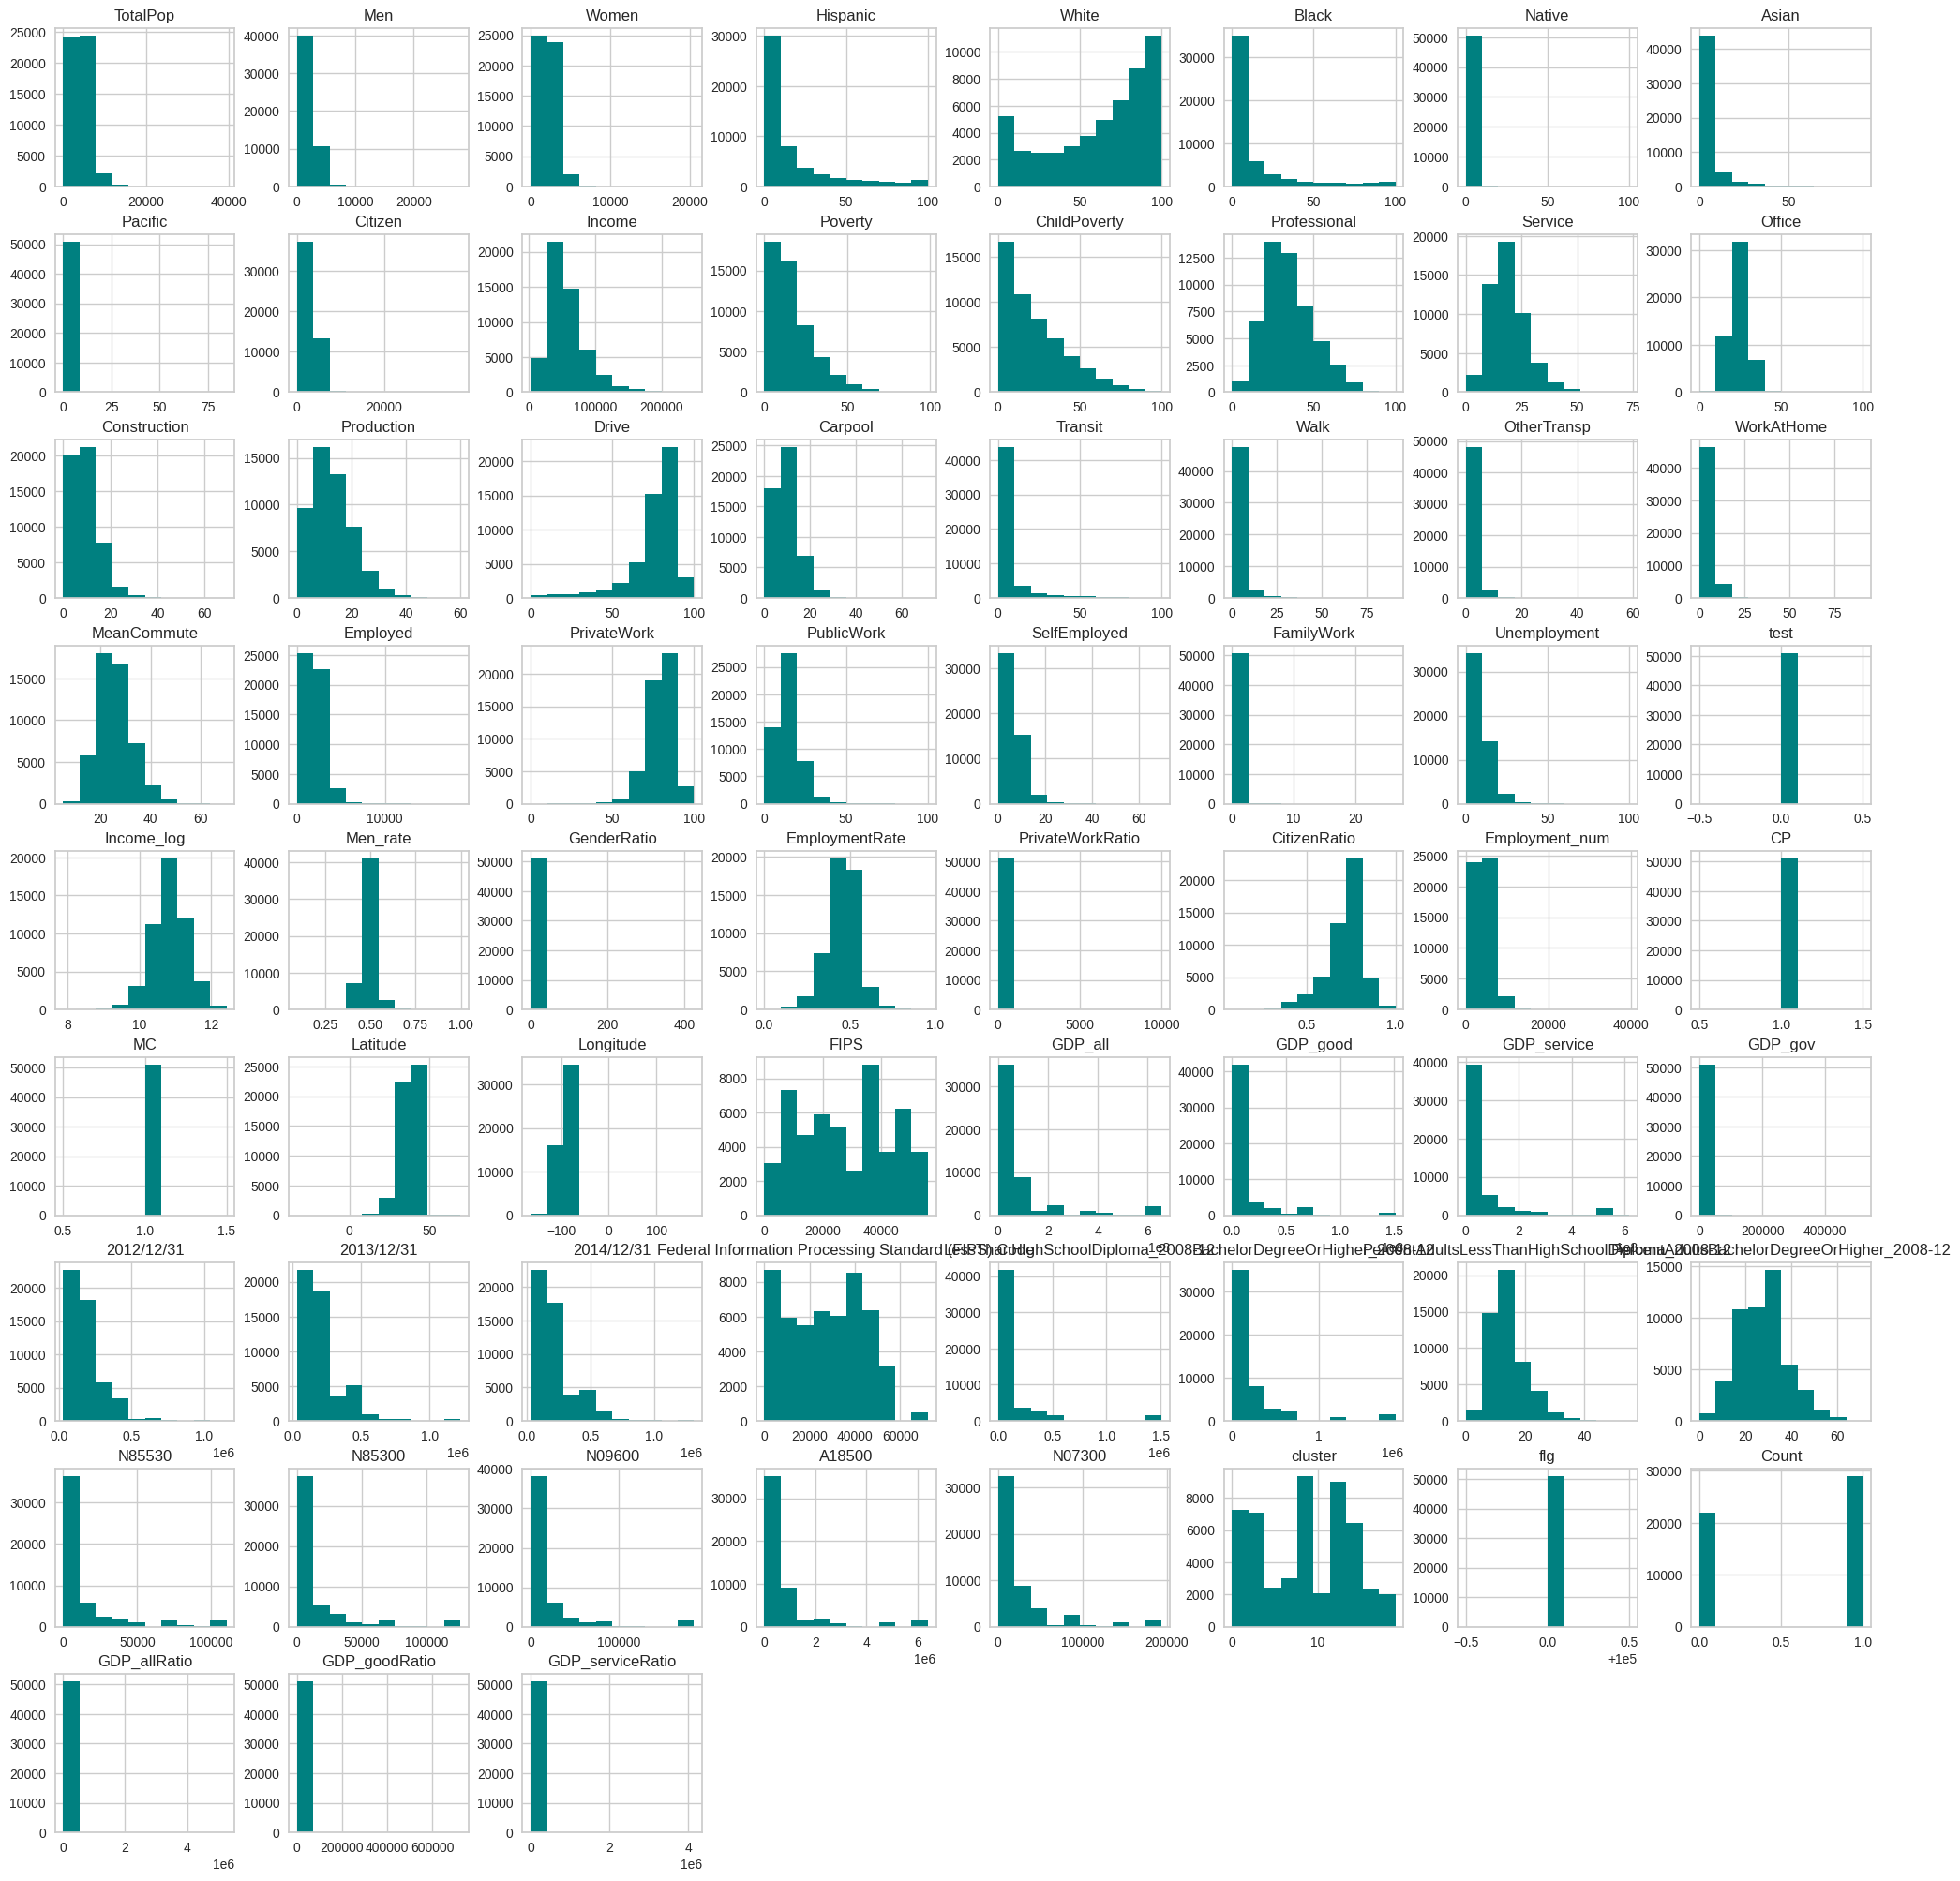

In [ ]:
# 学習データの分布の確認
df.hist(bins=10, figsize=(25,25), color='teal')

array([[<Axes: title={'center': 'TotalPop'}>,
        <Axes: title={'center': 'Men'}>,
        <Axes: title={'center': 'Women'}>,
        <Axes: title={'center': 'Hispanic'}>,
        <Axes: title={'center': 'White'}>,
        <Axes: title={'center': 'Black'}>,
        <Axes: title={'center': 'Native'}>,
        <Axes: title={'center': 'Asian'}>],
       [<Axes: title={'center': 'Pacific'}>,
        <Axes: title={'center': 'Citizen'}>,
        <Axes: title={'center': 'Poverty'}>,
        <Axes: title={'center': 'ChildPoverty'}>,
        <Axes: title={'center': 'Professional'}>,
        <Axes: title={'center': 'Service'}>,
        <Axes: title={'center': 'Office'}>,
        <Axes: title={'center': 'Construction'}>],
       [<Axes: title={'center': 'Production'}>,
        <Axes: title={'center': 'Drive'}>,
        <Axes: title={'center': 'Carpool'}>,
        <Axes: title={'center': 'Transit'}>,
        <Axes: title={'center': 'Walk'}>,
        <Axes: title={'center': 'OtherTransp'}>,
   

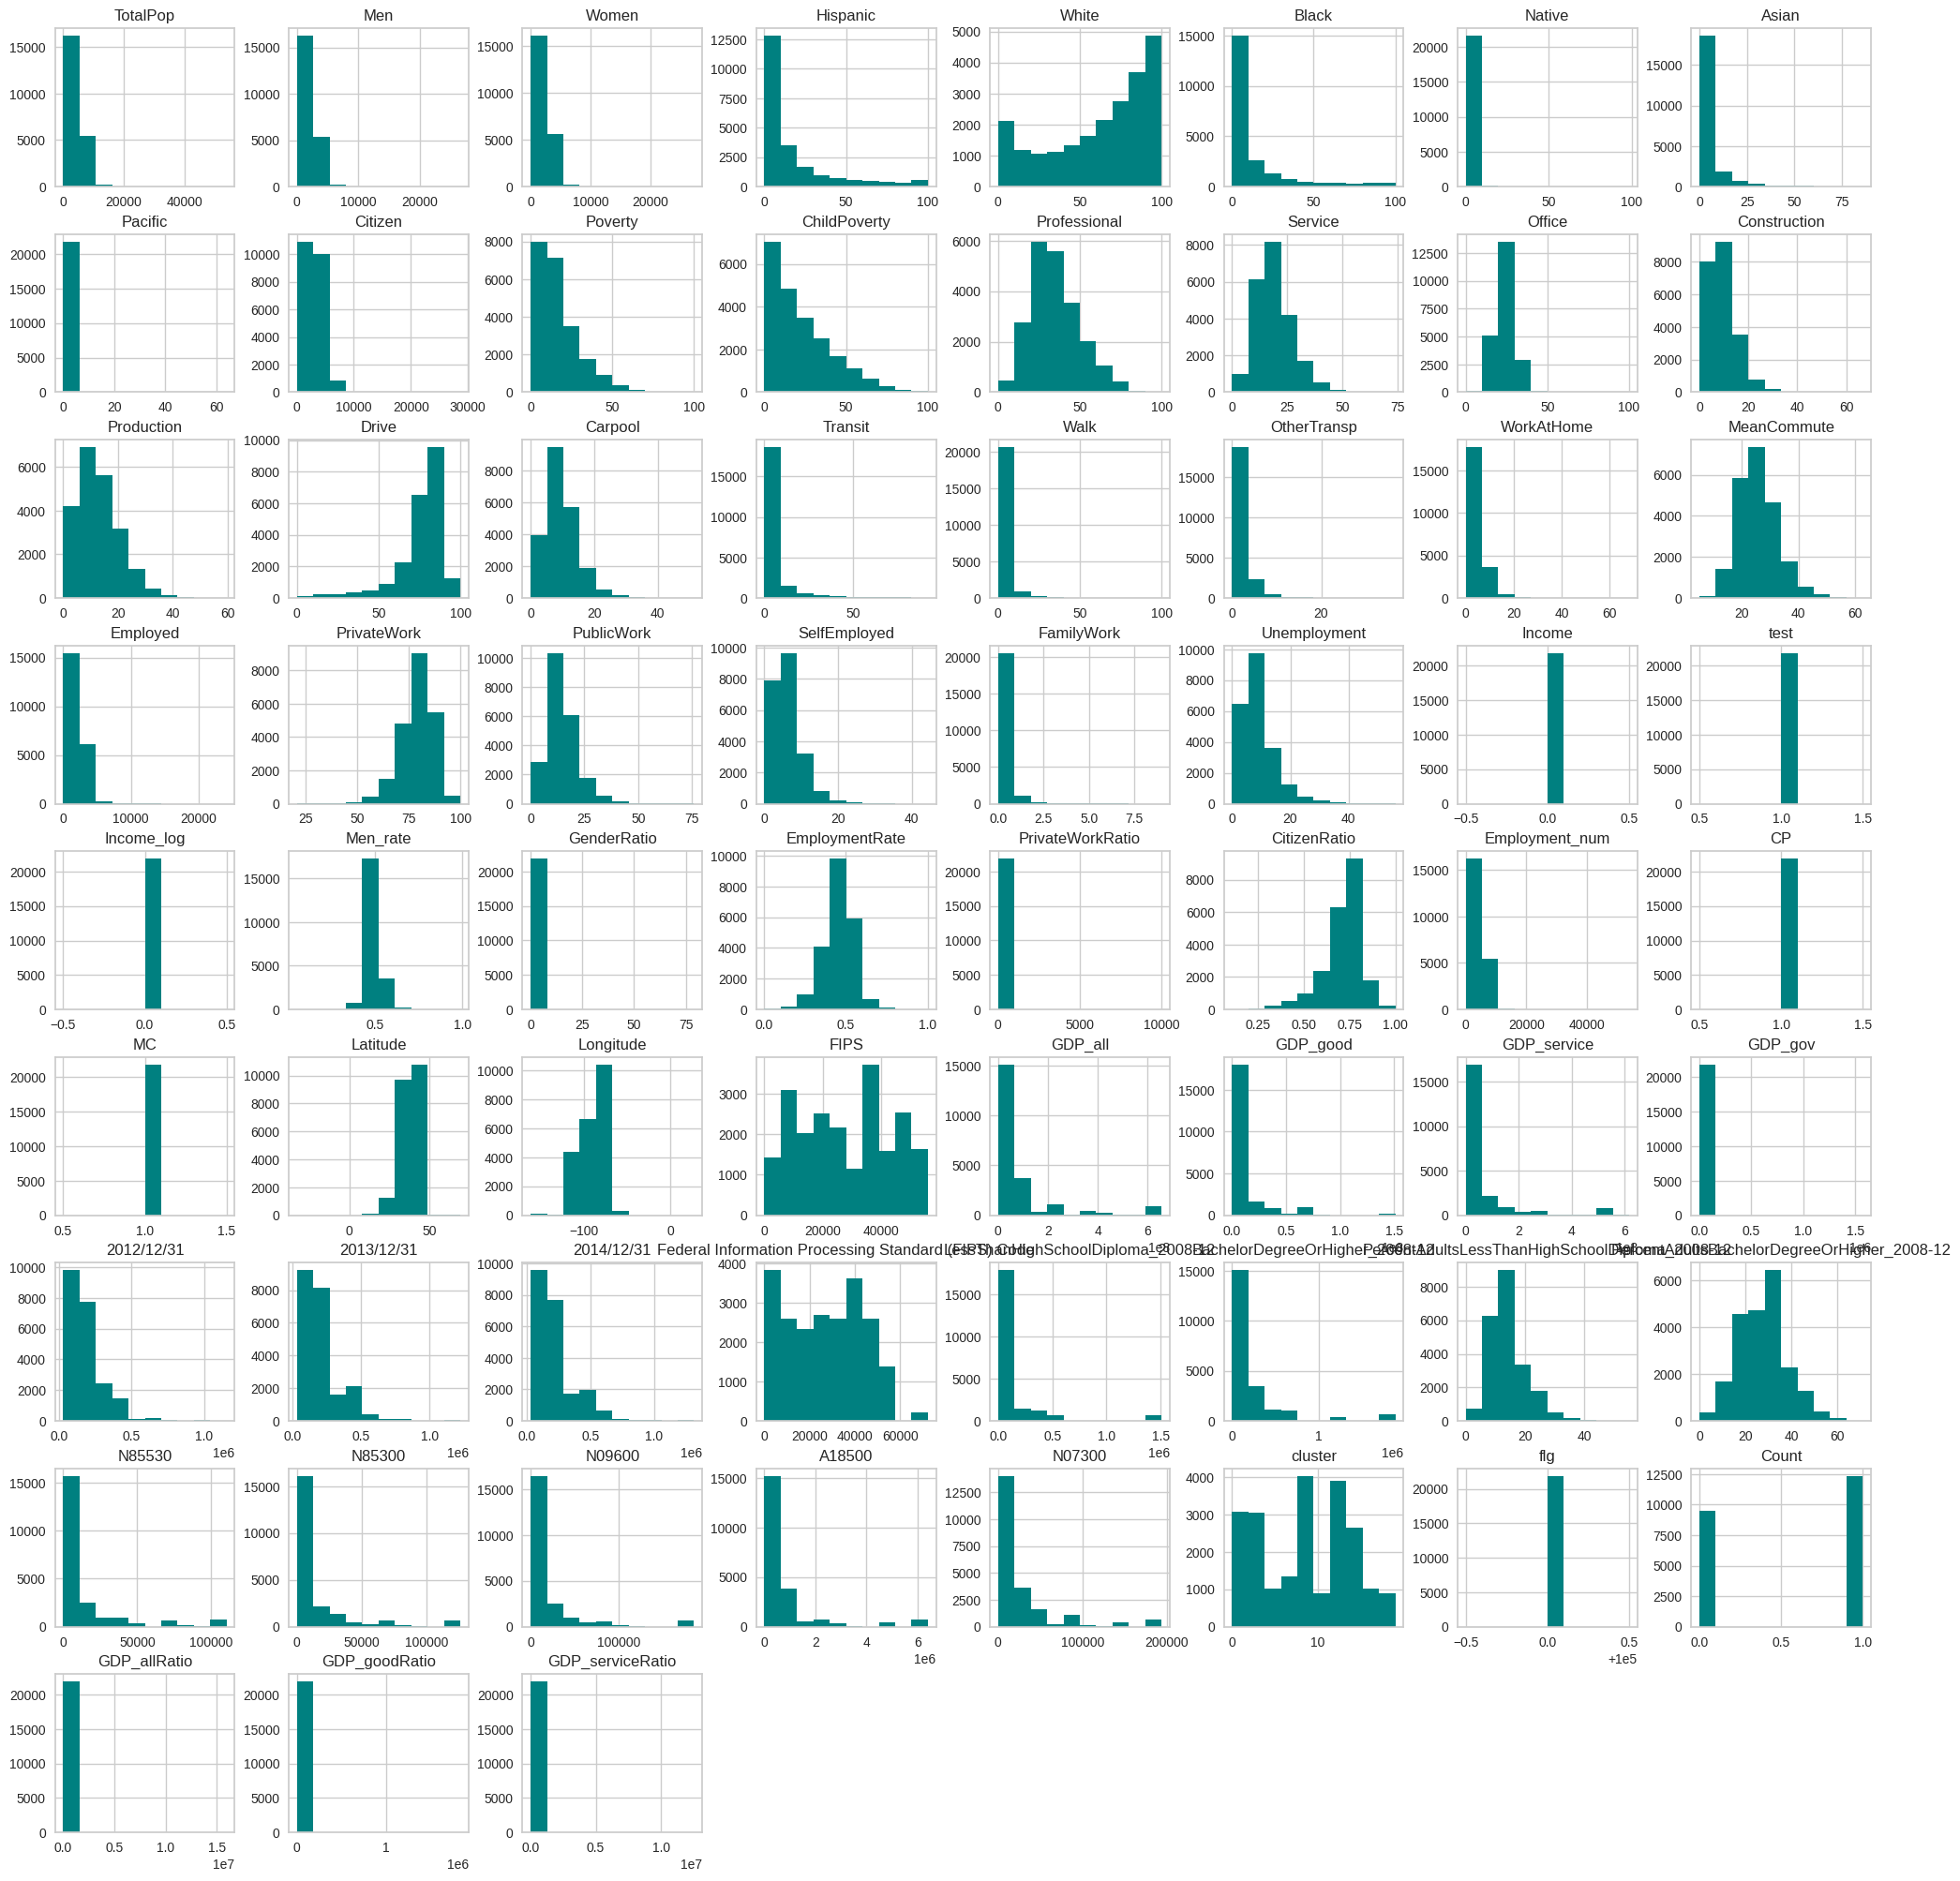

In [ ]:
# 評価データの分布の確認
test.hist(bins=10, figsize=(25,25), color='teal')

In [ ]:
columns = df.columns.values
print(columns)

['id' 'State' 'County' 'TotalPop' 'Men' 'Women' 'Hispanic' 'White' 'Black'
 'Native' 'Asian' 'Pacific' 'Citizen' 'Income' 'Poverty' 'ChildPoverty'
 'Professional' 'Service' 'Office' 'Construction' 'Production' 'Drive'
 'Carpool' 'Transit' 'Walk' 'OtherTransp' 'WorkAtHome' 'MeanCommute'
 'Employed' 'PrivateWork' 'PublicWork' 'SelfEmployed' 'FamilyWork'
 'Unemployment' 'test' 'Income_log' 'Men_rate' 'S&C' 'GenderRatio'
 'EmploymentRate' 'PrivateWorkRatio' 'CitizenRatio' 'Employment_num' 'CP'
 'MC' 'latlng' 'Latitude' 'Longitude' 'FIPS' 'GDP_all' 'GDP_good'
 'GDP_service' 'GDP_gov' 'Metro' '2012/12/31' '2013/12/31' '2014/12/31'
 'Federal Information Processing Standard (FIPS) Code'
 'LessThanHighSchoolDiploma_2008-12' 'BachelorDegreeOrHigher_2008-12'
 'PercentAdultsLessThanHighSchoolDiploma_2008-12'
 'PercentAdultsBachelorDegreeOrHigher_2008-12' 'N85530' 'N85300' 'N09600'
 'A18500' 'N07300' 'cluster' 'flg' 'Count' 'GDP_allRatio' 'GDP_goodRatio'
 'GDP_serviceRatio']


In [ ]:
le = LabelEncoder()

r = []
s1 = pd.Series(df['Income_log'])
df_original = df

for c in columns:
    if df[c].dtype == object:
        df[c] = le.fit_transform(df[c])
    df = df.dropna(subset=[c])
    s2 = pd.Series(df[c])
    if not np.isnan(s1.corr(s2)):
        r.append([abs(s1.corr(s2)), c])
    else:
        print(s1.corr(s2), c)

print('-'*80)

r.sort(reverse=True, key=lambda x:x[0])
for a in r:
    print(a)

nan test
nan CP
nan MC
nan flg
--------------------------------------------------------------------------------
[1.0, 'Income_log']
[0.9398342798632685, 'Income']
[0.8464463757805523, 'Poverty']
[0.7749765546419948, 'ChildPoverty']
[0.7044841297708153, 'Professional']
[0.6250745483594624, 'Service']
[0.5915763000738177, 'Unemployment']
[0.5606294394775833, 'EmploymentRate']
[0.4687307336433786, 'Production']
[0.3966853379849835, 'White']
[0.3819678427197633, 'Black']
[0.38053669736970064, 'Employed']
[0.3648126888949855, 'PercentAdultsBachelorDegreeOrHigher_2008-12']
[0.33377931873259814, 'WorkAtHome']
[0.30134126937027655, '2012/12/31']
[0.2935901976096063, 'PercentAdultsLessThanHighSchoolDiploma_2008-12']
[0.29280529861223237, '2013/12/31']
[0.2862137151914089, '2014/12/31']
[0.27824746642868314, 'Carpool']
[0.27175535269774015, 'Construction']
[0.25991942091043463, 'Hispanic']
[0.25509446049141016, 'Asian']
[0.2520687188566989, 'Citizen']
[0.2166126604449533, 'Men']
[0.2141644377638

In [ ]:
print(df_original.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 51030 entries, 0 to 51029
Data columns (total 73 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   id                                                   51030 non-null  int64  
 1   State                                                51030 non-null  object 
 2   County                                               51030 non-null  object 
 3   TotalPop                                             51030 non-null  int64  
 4   Men                                                  51030 non-null  int64  
 5   Women                                                51030 non-null  int64  
 6   Hispanic                                             51030 non-null  float64
 7   White                                                51030 non-null  float64
 8   Black                                                51030 non-nul

In [ ]:
# 特徴量の数（変数探索用）
NUM_COLUMS = 65

In [ ]:
columns2 = [[] for i in range(NUM_COLUMS)]

'''
for j in range(0,36):
    columns2[j].append( 'State')
    columns2[j].append( 'County')
'''

for i in range(2,NUM_COLUMS+2):
    for j in range(0,NUM_COLUMS):
        if j >= i-1:
            columns2[j].append(r[i][1])

for j in range(0,NUM_COLUMS):
    columns2[j].append( 'Income')
    columns2[j].append( 'Income_log')
    columns2[j].append( 'test')
    columns2[j].append( 'id')

print(columns2)

[['Income', 'Income_log', 'test', 'id'], ['Poverty', 'Income', 'Income_log', 'test', 'id'], ['Poverty', 'ChildPoverty', 'Income', 'Income_log', 'test', 'id'], ['Poverty', 'ChildPoverty', 'Professional', 'Income', 'Income_log', 'test', 'id'], ['Poverty', 'ChildPoverty', 'Professional', 'Service', 'Income', 'Income_log', 'test', 'id'], ['Poverty', 'ChildPoverty', 'Professional', 'Service', 'Unemployment', 'Income', 'Income_log', 'test', 'id'], ['Poverty', 'ChildPoverty', 'Professional', 'Service', 'Unemployment', 'EmploymentRate', 'Income', 'Income_log', 'test', 'id'], ['Poverty', 'ChildPoverty', 'Professional', 'Service', 'Unemployment', 'EmploymentRate', 'Production', 'Income', 'Income_log', 'test', 'id'], ['Poverty', 'ChildPoverty', 'Professional', 'Service', 'Unemployment', 'EmploymentRate', 'Production', 'White', 'Income', 'Income_log', 'test', 'id'], ['Poverty', 'ChildPoverty', 'Professional', 'Service', 'Unemployment', 'EmploymentRate', 'Production', 'White', 'Black', 'Income', 'I

In [ ]:
df[columns2[NUM_COLUMS-1]].info()
df[columns2[NUM_COLUMS-1]].head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 51030 entries, 0 to 51029
Data columns (total 68 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Poverty                                              51030 non-null  float64
 1   ChildPoverty                                         51030 non-null  float64
 2   Professional                                         51030 non-null  float64
 3   Service                                              51030 non-null  float64
 4   Unemployment                                         51030 non-null  float64
 5   EmploymentRate                                       51030 non-null  float64
 6   Production                                           51030 non-null  float64
 7   White                                                51030 non-null  float64
 8   Black                                                51030 non-nul

,Poverty,ChildPoverty,Professional,Service,Unemployment,EmploymentRate,Production,White,Black,Employed,...,Pacific,GDP_service,GDP_allRatio,GDP_serviceRatio,cluster,GenderRatio,Income,Income_log,test,id
0,7.9,8.0,49.3,13.7,8.3,0.499158,1.9,64.7,10.8,2075,...,0.0,13576756.0,4016.498196,3265.998557,6,0.964556,86250.0,11.365017,0,0
1,16.6,34.4,22.1,23.0,11.9,0.518294,10.3,58.7,14.4,2564,...,0.0,13576756.0,3375.092581,2744.442288,6,1.137857,51448.0,10.848346,0,976
2,17.0,7.3,53.2,12.3,8.3,0.499653,7.2,71.8,10.4,2158,...,0.0,13576756.0,3865.844640,3143.495254,6,1.195730,103618.0,11.548476,0,1679
3,23.2,42.5,30.8,20.4,11.4,0.493221,11.7,46.7,20.4,3274,...,0.0,13576756.0,2515.303254,2045.308225,6,1.017016,43692.0,10.684943,0,5135
4,17.6,26.7,21.0,25.3,16.9,0.407933,7.8,59.9,9.3,2643,...,0.0,13576756.0,2577.030869,2095.501775,6,0.961550,29366.0,10.287627,0,5345


In [ ]:
df_original = pd.concat([df_original, test], ignore_index=True)
df_original = df_original[columns2[NUM_COLUMS-1]]
columns_oroginal = df_original.columns.values
le = LabelEncoder()

for c in columns_oroginal:
    if df_original[c].dtype == object:
        if c != 'id':
           df_original[c] = le.fit_transform(df_original[c])
    df_original = df_original.dropna(subset=[c])

In [ ]:
df_original[columns2[NUM_COLUMS-1]].info()
#df_original.to_csv('drive/My Drive/Colab Notebooks/国勢/df_original.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72901 entries, 0 to 72900
Data columns (total 68 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Poverty                                              72901 non-null  float64
 1   ChildPoverty                                         72901 non-null  float64
 2   Professional                                         72901 non-null  float64
 3   Service                                              72901 non-null  float64
 4   Unemployment                                         72901 non-null  float64
 5   EmploymentRate                                       72901 non-null  float64
 6   Production                                           72901 non-null  float64
 7   White                                                72901 non-null  float64
 8   Black                                                72901 non-nul

In [ ]:
"""
# LightGBMの適切な特徴量の数探索。そんなには時間が掛からない。
accuracy_score_LBGM_train = []
accuracy_score_LBGM_test = []

for i in range(1,NUM_COLUMS):

  # Setting data
    df2 = df_original[columns2[i]].query('test == 0')
    print('X factor:', df2.columns.values)
    train_set, test_set = train_test_split(df2, test_size=0.2, random_state = 123)
    drop_col = ['Income', 'Income_log', 'id']
    X_train = train_set.drop(drop_col, axis=1)
    y_train = train_set['Income_log']
    X_test = test_set.drop(drop_col, axis=1)
    y_test = test_set['Income_log']

    dtrain = lgb.Dataset(X_train, y_train)
    dvalid = lgb.Dataset(X_test, y_test)

  # LBGM
    params = {
       'boosting_type': 'gbdt',
       "objective" : "regression_l1",
       "metric" : "mean_absolute_error",
       "learning_rate" : 0.05,
       "num_leaves" : 32,
       "subsample" : 0.7,
       "subsample_freq" : 1,
       "feature_fraction" : 0.8,
       "min_data_in_leaf" : 50,
       "min_sum_hessian_in_leaf" : 50,
       "n_estimators" : 1000,
       "random_state" : 123,
       "importance_type" : "gain",
     }

    verbose_eval = 0  # この数字を1にすると学習時のスコア推移がコマンドライン表示される

    #モデル
    lgb_model = lgb.LGBMRegressor(**params)
    lgb_model.fit( X_train, y_train,
                   eval_set = [(X_train, y_train), (X_test, y_test)],
                   callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=True), lgb.log_evaluation(verbose_eval)], # early_stopping用コールバック関数
                 )
    y_train_pred = lgb_model.predict(X_train)
    y_test_pred = lgb_model.predict(X_test)
    accuracy_score_LBGM_train.append(np.sqrt(MSE(np.exp(y_train), np.exp(y_train_pred))))
    accuracy_score_LBGM_test.append(np.sqrt(MSE(np.exp(y_test), np.exp(y_test_pred))))
    print('Accuracy score: Train %.2f, Test %.2f' % (
            np.sqrt(MSE(np.exp(y_train), np.exp(y_train_pred))),
            np.sqrt(MSE(np.exp(y_test), np.exp(y_test_pred)))
          ))
    print('-'*80)

# Plot
n_factor = range(1,NUM_COLUMS)
fig = plt.figure(figsize=(20,20))
fig, ax = plt.subplots()
ax.set_xlabel("Number of X factor")
ax.set_ylabel("Accuracy score")
plt.ylim(7000,14000)
ax.plot(n_factor, accuracy_score_LBGM_train, marker=".", color="steelblue", lw=1, label="LBGM_train")
ax.plot(n_factor, accuracy_score_LBGM_test, marker="o", color="steelblue", lw=1, label="LBGM_test")
ax.legend()
plt.show()
"""

'\n# LightGBMの適切な特徴量の数探索。そんなには時間が掛からない。\naccuracy_score_LBGM_train = []\naccuracy_score_LBGM_test = []\n\nfor i in range(1,NUM_COLUMS):\n\n  # Setting data\n    df2 = df_original[columns2[i]].query(\'test == 0\')\n    print(\'X factor:\', df2.columns.values)\n    train_set, test_set = train_test_split(df2, test_size=0.2, random_state = 123)\n    drop_col = [\'Income\', \'Income_log\', \'id\']\n    X_train = train_set.drop(drop_col, axis=1)\n    y_train = train_set[\'Income_log\']\n    X_test = test_set.drop(drop_col, axis=1)\n    y_test = test_set[\'Income_log\']\n\n    dtrain = lgb.Dataset(X_train, y_train)\n    dvalid = lgb.Dataset(X_test, y_test)\n\n  # LBGM\n    params = {\n       \'boosting_type\': \'gbdt\',\n       "objective" : "regression_l1",\n       "metric" : "mean_absolute_error",\n       "learning_rate" : 0.05,\n       "num_leaves" : 32,\n       "subsample" : 0.7,\n       "subsample_freq" : 1,\n       "feature_fraction" : 0.8,\n       "min_data_in_leaf" : 50,\n       "min_

In [ ]:
"""
# CatBoostの適切な特徴量の数探索。実行に46分かかる！！！
accuracy_score_CAT_train = []
accuracy_score_CAT_test = []

for i in range(1,NUM_COLUMS):

  # Setting data
    df2 = df_original[columns2[i]].query('test == 0')
    print('X factor:', df2.columns.values)
    train_set, test_set = train_test_split(df2, test_size=0.2, random_state = 123)
    drop_col = ['Income', 'Income_log', 'id']
    X_train = train_set.drop(drop_col, axis=1)
    y_train = train_set['Income_log']
    X_test = test_set.drop(drop_col, axis=1)
    y_test = test_set['Income_log']

    train_pool = Pool(X_train, y_train)
    test_pool = Pool(X_test, y_test)

  # CAT
    params = {
    "loss_function" : 'RMSE',
    'num_boost_round': 2000,
    'early_stopping_rounds': 100,
    }

  #モデル
    cat_model = CatBoostRegressor(**params)
    cat_model.fit(train_pool)

    y_train_pred = cat_model.predict(X_train)
    y_test_pred = cat_model.predict(X_test)
    accuracy_score_CAT_train.append(np.sqrt(MSE(np.exp(y_train), np.exp(y_train_pred))))
    accuracy_score_CAT_test.append(np.sqrt(MSE(np.exp(y_test), np.exp(y_test_pred))))
    print('Accuracy score: Train %.2f, Test %.2f' % (
            np.sqrt(MSE(np.exp(y_train), np.exp(y_train_pred))),
            np.sqrt(MSE(np.exp(y_test), np.exp(y_test_pred)))
          ))
    print('-'*80)

# Plot
n_factor = range(1,NUM_COLUMS)
fig = plt.figure(figsize=(20,20))
fig, ax = plt.subplots()
ax.set_xlabel("Number of X factor")
ax.set_ylabel("Accuracy score")
plt.ylim(7000,14000)
ax.plot(n_factor, accuracy_score_CAT_train, marker=".", color="steelblue", lw=1, label="CAT_train")
ax.plot(n_factor, accuracy_score_CAT_test, marker="o", color="steelblue", lw=1, label="CAT_test")
ax.legend()
plt.show()

#結果表示
c = 1
for i in accuracy_score_CAT_test:
  print('c = %.i, RMSE = %.i' %(
     c,i
  ))
  c = c + 1
"""

"""
以下、出力結果
c = 1, RMSE = 17095
c = 2, RMSE = 16942
c = 3, RMSE = 13270
c = 4, RMSE = 13191
c = 5, RMSE = 13170
c = 6, RMSE = 12805
c = 7, RMSE = 12551
c = 8, RMSE = 12256
c = 9, RMSE = 11886
c = 10, RMSE = 11817
c = 11, RMSE = 11309
c = 12, RMSE = 11150
c = 13, RMSE = 10720
c = 14, RMSE = 10654
c = 15, RMSE = 10601
c = 16, RMSE = 10582
c = 17, RMSE = 10567
c = 18, RMSE = 10542
c = 19, RMSE = 10526
c = 20, RMSE = 10499
c = 21, RMSE = 10428
c = 22, RMSE = 10266
c = 23, RMSE = 10250
c = 24, RMSE = 10259
c = 25, RMSE = 10069
c = 26, RMSE = 9992
c = 27, RMSE = 10009
c = 28, RMSE = 10003
c = 29, RMSE = 9954
c = 30, RMSE = 9973
c = 31, RMSE = 9962
c = 32, RMSE = 9943
c = 33, RMSE = 9864
c = 34, RMSE = 9864
c = 35, RMSE = 9833
c = 36, RMSE = 9740
c = 37, RMSE = 9760
c = 38, RMSE = 9790
c = 39, RMSE = 9778
c = 40, RMSE = 9771
c = 41, RMSE = 9780
c = 42, RMSE = 9772
c = 43, RMSE = 9706
c = 44, RMSE = 9735
c = 45, RMSE = 9687
c = 46, RMSE = 9679
c = 47, RMSE = 9648
c = 48, RMSE = 9640
c = 49, RMSE = 9637
c = 50, RMSE = 9616
c = 51, RMSE = 9653
c = 52, RMSE = 9611
c = 53, RMSE = 9597
c = 54, RMSE = 9648
c = 55, RMSE = 9618
c = 56, RMSE = 9638
c = 57, RMSE = 9602
c = 58, RMSE = 9611
c = 59, RMSE = 9589　←採用
c = 60, RMSE = 9615
c = 61, RMSE = 9606
c = 62, RMSE = 9570
c = 63, RMSE = 9589
c = 64, RMSE = 9613
"""

'\n以下、出力結果\nc = 1, RMSE = 17095\nc = 2, RMSE = 16942\nc = 3, RMSE = 13270\nc = 4, RMSE = 13191\nc = 5, RMSE = 13170\nc = 6, RMSE = 12805\nc = 7, RMSE = 12551\nc = 8, RMSE = 12256\nc = 9, RMSE = 11886\nc = 10, RMSE = 11817\nc = 11, RMSE = 11309\nc = 12, RMSE = 11150\nc = 13, RMSE = 10720\nc = 14, RMSE = 10654\nc = 15, RMSE = 10601\nc = 16, RMSE = 10582\nc = 17, RMSE = 10567\nc = 18, RMSE = 10542\nc = 19, RMSE = 10526\nc = 20, RMSE = 10499\nc = 21, RMSE = 10428\nc = 22, RMSE = 10266\nc = 23, RMSE = 10250\nc = 24, RMSE = 10259\nc = 25, RMSE = 10069\nc = 26, RMSE = 9992\nc = 27, RMSE = 10009\nc = 28, RMSE = 10003\nc = 29, RMSE = 9954\nc = 30, RMSE = 9973\nc = 31, RMSE = 9962\nc = 32, RMSE = 9943\nc = 33, RMSE = 9864\nc = 34, RMSE = 9864\nc = 35, RMSE = 9833\nc = 36, RMSE = 9740\nc = 37, RMSE = 9760\nc = 38, RMSE = 9790\nc = 39, RMSE = 9778\nc = 40, RMSE = 9771\nc = 41, RMSE = 9780\nc = 42, RMSE = 9772\nc = 43, RMSE = 9706\nc = 44, RMSE = 9735\nc = 45, RMSE = 9687\nc = 46, RMSE = 9679\nc = 

In [ ]:
# 特徴量の数（モデル作成用）
NUM_COLUMS_MODEL = 59

In [ ]:
# LightGBMモデル
df2 = df_original[columns2[NUM_COLUMS_MODEL]].query('test == 0')
print('X factor:', df2.columns.values)
train_set, test_set = train_test_split(df2, test_size=0.2, random_state = 123)
drop_col = ['Income', 'Income_log','id']
X_train = train_set.drop(drop_col, axis=1)
y_train = train_set['Income_log']
X_test = test_set.drop(drop_col, axis=1)
y_test = test_set['Income_log']

dtrain = lgb.Dataset(X_train, y_train)
dvalid = lgb.Dataset(X_test, y_test)

params = {
       'boosting_type': 'gbdt',
       "objective" : "regression_l1",
       "metric" : "mean_absolute_error",
       "learning_rate" : 0.05,
       "num_leaves" : 32,
       "subsample" : 0.7,
       "subsample_freq" : 1,
       "feature_fraction" : 0.8,
       "min_data_in_leaf" : 50,
       "min_sum_hessian_in_leaf" : 50,
       "n_estimators" : 5000,
       "random_state" : 123,
       "importance_type" : "gain",
     }

verbose_eval = 0  # この数字を1にすると学習時のスコア推移がコマンドライン表示される

#モデル
lgb_model = lgb.LGBMRegressor(**params)
lgb_model.fit( X_train, y_train,
               eval_set = [(X_train, y_train), (X_test, y_test)],
               callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=True), lgb.log_evaluation(verbose_eval)], # early_stopping用コールバック関数
             )

#訓練データの予測・精度評価
print('-'*80)
y_train_pred = lgb_model.predict(X_train)
y_test_pred = lgb_model.predict(X_test)
rmse_train = np.sqrt(MSE(np.exp(y_train), np.exp(y_train_pred)))
rmse_test = np.sqrt(MSE(np.exp(y_test), np.exp(y_test_pred)))
#rmse_train = np.sqrt(MSE(y_train, y_train_pred))
#rmse_test = np.sqrt(MSE(y_test, y_test_pred))
print('RMSE :  Train %.2f, Test %.2f' % (rmse_train, rmse_test))

X factor: ['Poverty' 'ChildPoverty' 'Professional' 'Service' 'Unemployment'
 'EmploymentRate' 'Production' 'White' 'Black' 'Employed'
 'PercentAdultsBachelorDegreeOrHigher_2008-12' 'WorkAtHome' '2012/12/31'
 'PercentAdultsLessThanHighSchoolDiploma_2008-12' '2013/12/31'
 '2014/12/31' 'Carpool' 'Construction' 'Hispanic' 'Asian' 'Citizen' 'Men'
 'Employment_num' 'TotalPop' 'MeanCommute' 'Walk' 'Women' 'Latitude'
 'N85530' 'N85300' 'N09600' 'Drive' 'A18500' 'N07300' 'latlng'
 'OtherTransp' 'BachelorDegreeOrHigher_2008-12' 'CitizenRatio'
 'SelfEmployed' 'Longitude'
 'Federal Information Processing Standard (FIPS) Code' 'Native' 'Men_rate'
 'Count' 'Transit' 'State' 'PrivateWork' 'Office' 'S&C'
 'LessThanHighSchoolDiploma_2008-12' 'County' 'GDP_good' 'Metro' 'GDP_gov'
 'GDP_goodRatio' 'PrivateWorkRatio' 'GDP_all' 'FIPS' 'Pacific' 'Income'
 'Income_log' 'test' 'id']
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=50, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_i

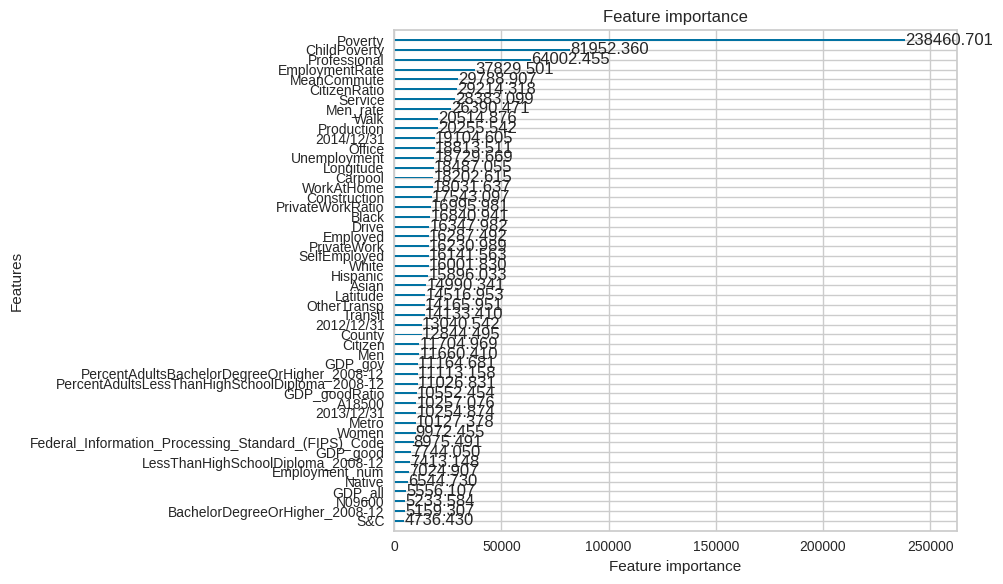

In [ ]:
# 特徴量重要度の可視化、Gain、特徴量が目的関数の減少にどの程度貢献したかを表す
feature_imp = pd.DataFrame(sorted(zip(lgb_model.feature_importances_, X_train.columns)), columns=['importance', 'feature'])
lgb.plot_importance(lgb_model, figsize=(10,6), max_num_features=50, importance_type='gain')
plt.tight_layout()
plt.show()
plt.close()

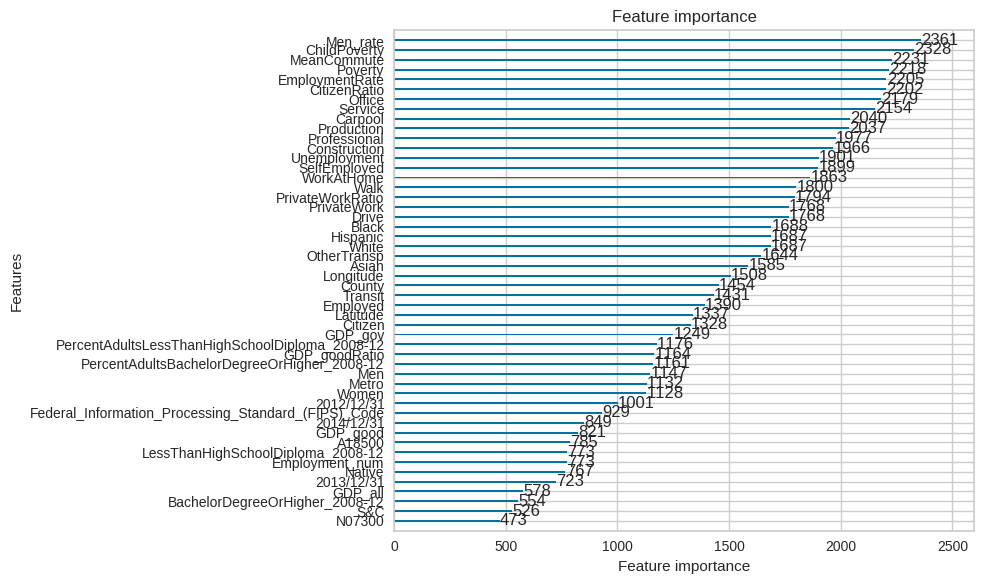

In [ ]:
# 特徴量重要度の可視化、Split、特徴量がモデルで使用された回数を表す
feature_imp = pd.DataFrame(sorted(zip(lgb_model.feature_importances_, X_train.columns)), columns=['importance', 'feature'])
lgb.plot_importance(lgb_model, figsize=(10,6), max_num_features=50, importance_type='split')
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
"""
#CatBoostのパラメータ探索(Pythonコード参考:https://qiita.com/shin_mura/items/8f1aa1ec90fa4ad6253e) 34分掛かる！
def objective(trial):
    # トレーニングデータとテストデータを分割
    df2 = df_original[columns2[NUM_COLUMS_MODEL]].query('test == 0')
    print('X factor:', df2.columns.values)
    train_set, test_set = train_test_split(df2, test_size=0.2, random_state = 123)
    drop_col = ['Income', 'Income_log', 'id']
    X_train = train_set.drop(drop_col, axis=1)
    y_train = train_set['Income_log']
    X_test = test_set.drop(drop_col, axis=1)
    y_test = test_set['Income_log']

    train_pool = Pool(X_train, y_train)
    test_pool = Pool(X_test, y_test)

    # パラメータの指定
    params = {
        'iterations' : trial.suggest_int('iterations', 50, 300),
        'depth' : trial.suggest_int('depth', 4, 10),
        'learning_rate' : trial.suggest_loguniform('learning_rate', 0.01, 0.3),
        'random_strength' :trial.suggest_int('random_strength', 0, 100),
        'bagging_temperature' :trial.suggest_loguniform('bagging_temperature', 0.01, 100.00),
        'od_type': trial.suggest_categorical('od_type', ['IncToDec', 'Iter']),
        'od_wait' :trial.suggest_int('od_wait', 10, 50)
    }

    # 学習
    model = CatBoostRegressor(**params)
    model.fit(train_pool)
    # 予測
    preds = model.predict(test_pool)
    pred_labels = np.rint(preds)
    # 精度の計算
    rmse_test = np.sqrt(MSE(np.exp(y_test), np.exp(y_test_pred)))
    return rmse_test

import optuna
if __name__ == '__main__':
    study = optuna.create_study()
    study.optimize(objective, n_trials=100)
    print(study.best_trial)
"""
"""
# 実行結果
[I 2023-12-01 13:21:05,891] Trial 99 finished with value: 9539.905706791555 and parameters: {'iterations': 140, 'depth': 9, 'learning_rate': 0.11066668300483272, 'random_strength': 63, 'bagging_temperature': 0.01176836093705893, 'od_type': 'IncToDec', 'od_wait': 35}. Best is trial 0 with value: 9539.905706791555.
"""

"\n# 実行結果\n[I 2023-12-01 13:21:05,891] Trial 99 finished with value: 9539.905706791555 and parameters: {'iterations': 140, 'depth': 9, 'learning_rate': 0.11066668300483272, 'random_strength': 63, 'bagging_temperature': 0.01176836093705893, 'od_type': 'IncToDec', 'od_wait': 35}. Best is trial 0 with value: 9539.905706791555.\n"

In [ ]:
# CatBoostモデル。LightGBMを実行してから行うこと。（Train、Testデータ設定をそちらでやっているため）
train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)

params = {
    "loss_function" : 'RMSE',
    'num_boost_round': 5000,
    'early_stopping_rounds': 100,
}

#モデル
cat_model = CatBoostRegressor(**params)
cat_model.fit(train_pool)

#訓練データの予測・精度評価
print('-'*80)
y_train_pred = cat_model.predict(X_train)
y_test_pred = cat_model.predict(X_test)
rmse_train = np.sqrt(MSE(np.exp(y_train), np.exp(y_train_pred)))
rmse_test = np.sqrt(MSE(np.exp(y_test), np.exp(y_test_pred)))
print('RMSE :  Train %.2f, Test %.2f' % (rmse_train, rmse_test))

ストリーミング出力は最後の 5000 行に切り捨てられました。
2:	learn: 0.4655211	total: 163ms	remaining: 4m 30s
3:	learn: 0.4587521	total: 220ms	remaining: 4m 35s
4:	learn: 0.4519831	total: 278ms	remaining: 4m 37s
5:	learn: 0.4454649	total: 333ms	remaining: 4m 37s
6:	learn: 0.4389003	total: 374ms	remaining: 4m 27s
7:	learn: 0.4325124	total: 429ms	remaining: 4m 27s
8:	learn: 0.4264049	total: 483ms	remaining: 4m 27s
9:	learn: 0.4207002	total: 546ms	remaining: 4m 32s
10:	learn: 0.4149652	total: 599ms	remaining: 4m 31s
11:	learn: 0.4092584	total: 642ms	remaining: 4m 26s
12:	learn: 0.4035683	total: 695ms	remaining: 4m 26s
13:	learn: 0.3981409	total: 734ms	remaining: 4m 21s
14:	learn: 0.3929071	total: 775ms	remaining: 4m 17s
15:	learn: 0.3875643	total: 800ms	remaining: 4m 9s
16:	learn: 0.3825096	total: 827ms	remaining: 4m 2s
17:	learn: 0.3775010	total: 862ms	remaining: 3m 58s
18:	learn: 0.3726718	total: 890ms	remaining: 3m 53s
19:	learn: 0.3679436	total: 920ms	remaining: 3m 49s
20:	learn: 0.3633084	total: 952ms	remainin

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [13:21:19] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "bagging_fraction", "feature_fraction", "gagging_freq", "lambda_l1", "num_leaves" } are not used.

  warnings.warn(smsg, UserWarning)


[0]	train-rmse:0.47861	valid-rmse:0.47326
[1]	train-rmse:0.47067	valid-rmse:0.46544
[2]	train-rmse:0.46291	valid-rmse:0.45782
[3]	train-rmse:0.45531	valid-rmse:0.45037
[4]	train-rmse:0.44790	valid-rmse:0.44310
[5]	train-rmse:0.44065	valid-rmse:0.43596
[6]	train-rmse:0.43357	valid-rmse:0.42902
[7]	train-rmse:0.42663	valid-rmse:0.42222
[8]	train-rmse:0.41986	valid-rmse:0.41560
[9]	train-rmse:0.41325	valid-rmse:0.40911
[10]	train-rmse:0.40678	valid-rmse:0.40277
[11]	train-rmse:0.40048	valid-rmse:0.39661
[12]	train-rmse:0.39431	valid-rmse:0.39057
[13]	train-rmse:0.38829	valid-rmse:0.38469
[14]	train-rmse:0.38240	valid-rmse:0.37894
[15]	train-rmse:0.37665	valid-rmse:0.37331
[16]	train-rmse:0.37103	valid-rmse:0.36780
[17]	train-rmse:0.36555	valid-rmse:0.36246
[18]	train-rmse:0.36019	valid-rmse:0.35721
[19]	train-rmse:0.35497	valid-rmse:0.35212
[20]	train-rmse:0.34986	valid-rmse:0.34715
[21]	train-rmse:0.34488	valid-rmse:0.34231
[22]	train-rmse:0.34002	valid-rmse:0.33759
[23]	train-rmse:0.335

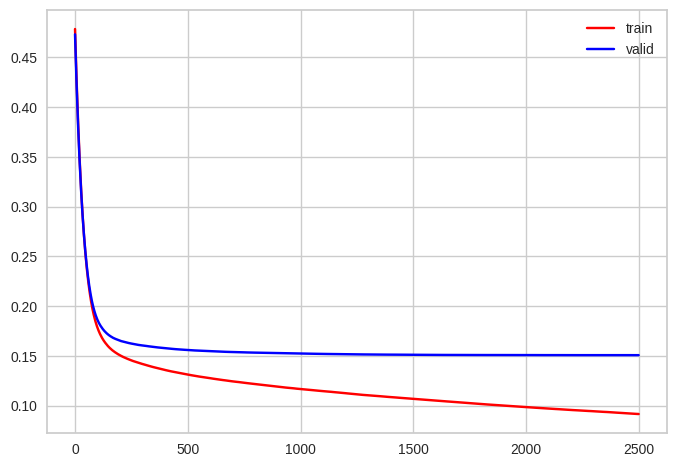

6014.824522493299
9673.574326163016


In [ ]:
# xgboostモデル
dtrain = xgb.DMatrix(X_train, y_train)
dvalid = xgb.DMatrix(X_test, y_test)

params = {
    "objective" : "reg:squarederror",
    "eval_metric" : "rmse",
    "learning_rate" : 0.02,  # 学習率
    "bagging_fraction" : 0.9, # 過学習抑制
    "feature_fraction" : 0.9,  # 過学習抑制
    "num_leaves" : 256,
    "gagging_freq" : 1,
    "lambda_l1" : 100
}

results_dict = {}

#モデル
xgb_model = xgb.train(
    params = params,
    dtrain = dtrain,
    evals = [(dtrain, "train"), (dvalid, "valid")],
    num_boost_round = 5000,
    early_stopping_rounds = 100,
    evals_result = results_dict
)

import matplotlib.pyplot as plt
plt.plot(results_dict["train"]["rmse"], color = "red", label = "train")
plt.plot(results_dict["valid"]["rmse"], color = "blue", label = "valid")
plt.legend()
plt.show()

#訓練データの予測・精度評価
y_train_pred = xgb_model.predict(xgb.DMatrix(X_train))
rmse_train = np.sqrt(MSE(np.exp(y_train), np.exp(y_train_pred)))
print(rmse_train)

#テストデータの予測・精度評価
y_test_pred = xgb_model.predict(xgb.DMatrix(X_test))
rmse_test = np.sqrt(MSE(np.exp(y_test), np.exp(y_test_pred)))
print(rmse_test)

In [ ]:
"""
# CatBoostのVoting(Pythonコードはhttps://potesara-tips.com/ensemble-voting/を参照)
# 50 SEEDの場合、86分（0.2）～130分（0.01）掛かる！！！ 30でも60分（0.2）！！！

loop_counts = 1
NUM_SEEDS = 50 # 作成するSEEDSの数

# モデル、正答率、予測値を保存するリストの初期化
cat_models = []
cat_accuracies = []
first_preds = []
first_preds = np.zeros((len(y_test), NUM_SEEDS))

# データ設定
df2 = df_original[columns2[NUM_COLUMS_MODEL]].query('test == 0')
train_set, test_set = train_test_split(df2, test_size=0.01, random_state = 123) # 0.01固定（データは可能な限り活用）
drop_col = ['Income', 'Income_log','id']
X_train = train_set.drop(drop_col, axis=1)
y_train = train_set['Income_log']
X_test = test_set.drop(drop_col, axis=1)
y_test = test_set['Income_log']

# シードを変えて予測（NUM_SEEDS個のモデルのアンサンブル）
for seed_no in range(NUM_SEEDS):

    # 学習データの数だけの数列
    row_no_list = list(range(len(y_train)))
    X_train2,X_test2,y_train2,y_test2 = train_test_split(X_train, y_train, test_size=0.2, random_state = 123 + seed_no) # SEEDの意味がなくなるので20%程度

    # CatBoostモデル
    train_pool = Pool(X_train2, y_train2)
    test_pool = Pool(X_test2, y_test2)

    params = {
        "loss_function" : 'RMSE',
        'num_boost_round': 5000,
        'early_stopping_rounds': 100,
        }

    #モデル
    cat_model = CatBoostRegressor(**params)
    cat_model.fit(train_pool)

    #訓練データの予測・精度評価
    print('-'*80)
    y_train_pred = cat_model.predict(X_train)
    y_test_pred = cat_model.predict(X_test)
    rmse_train = np.sqrt(MSE(np.exp(y_train), np.exp(y_train_pred)))
    rmse_test = np.sqrt(MSE(np.exp(y_test), np.exp(y_test_pred)))
    print('RMSE :  Train %.2f, Test %.2f' % (rmse_train, rmse_test))

    # 学習が終わったモデル・正答率をリストに入れておく
    cat_models.append(cat_model)
    cat_accuracies.append(rmse_test)

    # 学習が終わったモデルの予測をリストに入れておく
    first_preds[:, loop_counts-1] = y_test_pred

    # 実行回数のカウント
    loop_counts += 1

#結果表示
c = 123
for i in cat_accuracies:
  print('random_state = %.i, RMSE = %.i' %(
     c,i
  ))
  c = c + 1

# 単独のモデルでの、テストデータの正答率
print('平均Accuracy: ', np.array(cat_accuracies).mean())

# データ格納用のnumpy行列を作成
first_preds_ave = pd.DataFrame(np.zeros((len(y_test), NUM_SEEDS)))

# 予測したクラスのデータをpandas.DataFrameに入れる
df_first_preds = pd.DataFrame(first_preds)

# 各列に、そのクラスを予測したモデルの数を入れる
first_preds_ave = df_first_preds

# 各行で、そのクラスを予測したモデルの平均を取る
pred_ave = np.average(np.array(first_preds_ave), axis=1)

# Accuracy を計算する
rmse_test = np.sqrt(MSE(np.exp(y_test), np.exp(pred_ave)))
print('Accuracy:', rmse_test)
"""

'\n# CatBoostのVoting(Pythonコードはhttps://potesara-tips.com/ensemble-voting/を参照)\n# 50 SEEDの場合、86分（0.2）～130分（0.01）掛かる！！！ 30でも60分（0.2）！！！\n\nloop_counts = 1\nNUM_SEEDS = 50 # 作成するSEEDSの数\n\n# モデル、正答率、予測値を保存するリストの初期化\ncat_models = []\ncat_accuracies = []\nfirst_preds = []\nfirst_preds = np.zeros((len(y_test), NUM_SEEDS))\n\n# データ設定\ndf2 = df_original[columns2[NUM_COLUMS_MODEL]].query(\'test == 0\')\ntrain_set, test_set = train_test_split(df2, test_size=0.01, random_state = 123) # 0.01固定（データは可能な限り活用）\ndrop_col = [\'Income\', \'Income_log\',\'id\']\nX_train = train_set.drop(drop_col, axis=1)\ny_train = train_set[\'Income_log\']\nX_test = test_set.drop(drop_col, axis=1)\ny_test = test_set[\'Income_log\']\n\n# シードを変えて予測（NUM_SEEDS個のモデルのアンサンブル）\nfor seed_no in range(NUM_SEEDS):\n\n    # 学習データの数だけの数列\n    row_no_list = list(range(len(y_train)))\n    X_train2,X_test2,y_train2,y_test2 = train_test_split(X_train, y_train, test_size=0.2, random_state = 123 + seed_no) # SEEDの意味がなくなるので20%程度\n\n    # Cat

X factor: ['Poverty' 'ChildPoverty' 'Professional' 'Service' 'Unemployment'
 'EmploymentRate' 'Production' 'White' 'Black' 'Employed'
 'PercentAdultsBachelorDegreeOrHigher_2008-12' 'WorkAtHome' '2012/12/31'
 'PercentAdultsLessThanHighSchoolDiploma_2008-12' '2013/12/31'
 '2014/12/31' 'Carpool' 'Construction' 'Hispanic' 'Asian' 'Citizen' 'Men'
 'Employment_num' 'TotalPop' 'MeanCommute' 'Walk' 'Women' 'Latitude'
 'N85530' 'N85300' 'N09600' 'Drive' 'A18500' 'N07300' 'latlng'
 'OtherTransp' 'BachelorDegreeOrHigher_2008-12' 'CitizenRatio'
 'SelfEmployed' 'Longitude'
 'Federal Information Processing Standard (FIPS) Code' 'Native' 'Men_rate'
 'Count' 'Transit' 'State' 'PrivateWork' 'Office' 'S&C'
 'LessThanHighSchoolDiploma_2008-12' 'County' 'GDP_good' 'Metro' 'GDP_gov'
 'GDP_goodRatio' 'PrivateWorkRatio' 'GDP_all' 'FIPS' 'Pacific' 'Income'
 'Income_log' 'test' 'id']


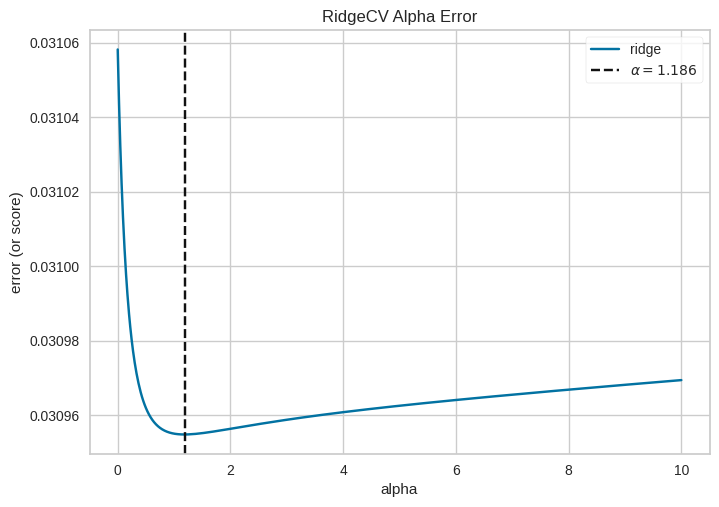

MSE: 11934.38267888177


In [ ]:
# 【参考】回帰（Ridge）モデル
df2 = df_original[columns2[NUM_COLUMS_MODEL]].query('test == 0')
print('X factor:', df2.columns.values)
train_set, test_set = train_test_split(df2, test_size=0.2, random_state = 123)
drop_col = ['Income', 'Income_log','id']
X_train = train_set.drop(drop_col, axis=1)
y_train = train_set['Income_log']
X_test = test_set.drop(drop_col, axis=1)
y_test = test_set['Income_log']

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

alphas = np.logspace(-10, 1, 500)
ridgeCV = RidgeCV(alphas = alphas)
visualizer = AlphaSelection(ridgeCV)
visualizer.fit(X_train, y_train)
visualizer.show()
plt.show()

ri_model = Ridge() #alpha =1.248
ri_model.fit(X_train, y_train)
y_test_pred = ri_model.predict(X_test)
score = np.sqrt(MSE(np.exp(y_test), np.exp(y_test_pred)))
print(f'MSE: {score}')

In [ ]:
# 【参考】ニューラルネットワークモデル
df2 = df_original[columns2[NUM_COLUMS_MODEL]].query('test == 0')
print('X factor:', df2.columns.values)
train_set, test_set = train_test_split(df2, test_size=0.2, random_state = 123)
drop_col = ['Income', 'Income_log','id']
X_train = train_set.drop(drop_col, axis=1)
y_train = train_set['Income_log']
X_test = test_set.drop(drop_col, axis=1)
y_test = test_set['Income_log']

# ニューラルネットモデルの構築
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Sequential()
model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1,activation='linear'))

model.compile(loss='mean_squared_error',optimizer='adam', metrics=['mae'])

# 学習の実行
# バリデーションデータもモデルに渡し、学習の進行とともにスコアがどう変わるかモニタリングする
batch_size = 128
epochs = 50
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs,
                    verbose=1, validation_data=(X_test, y_test), callbacks=[early_stopping])

# 予測
y_test_pred = model.predict(X_test)
score = np.sqrt(MSE(np.exp(y_test), np.exp(y_test_pred)))
print(f'MSE: {score}')

X factor: ['Poverty' 'ChildPoverty' 'Professional' 'Service' 'Unemployment'
 'EmploymentRate' 'Production' 'White' 'Black' 'Employed'
 'PercentAdultsBachelorDegreeOrHigher_2008-12' 'WorkAtHome' '2012/12/31'
 'PercentAdultsLessThanHighSchoolDiploma_2008-12' '2013/12/31'
 '2014/12/31' 'Carpool' 'Construction' 'Hispanic' 'Asian' 'Citizen' 'Men'
 'Employment_num' 'TotalPop' 'MeanCommute' 'Walk' 'Women' 'Latitude'
 'N85530' 'N85300' 'N09600' 'Drive' 'A18500' 'N07300' 'latlng'
 'OtherTransp' 'BachelorDegreeOrHigher_2008-12' 'CitizenRatio'
 'SelfEmployed' 'Longitude'
 'Federal Information Processing Standard (FIPS) Code' 'Native' 'Men_rate'
 'Count' 'Transit' 'State' 'PrivateWork' 'Office' 'S&C'
 'LessThanHighSchoolDiploma_2008-12' 'County' 'GDP_good' 'Metro' 'GDP_gov'
 'GDP_goodRatio' 'PrivateWorkRatio' 'GDP_all' 'FIPS' 'Pacific' 'Income'
 'Income_log' 'test' 'id']
Epoch 1/50
319/319 [==============================] - 3s 5ms/step - loss: 5.5291 - mae: 1.4583 - val_loss: 0.7858 - val_mae: 0.6

In [ ]:
# アンサンブル(Pythonコードはhttps://potesara-tips.com/ensemble-voting/を参照)

def xgb_train_cv(X_train_cv, y_train_cv, X_eval_cv, y_eval_cv, X_test, y_test, loop_counts):
    # データを格納する
    xgb_train = xgb.DMatrix(X_train_cv, label=y_train_cv)
    xgb_eval = xgb.DMatrix(X_eval_cv, label=y_eval_cv)
    xgb_test = xgb.DMatrix(X_test, label=y_test)

    params = {
    "objective" : "reg:squarederror",
    "eval_metric" : "rmse",
    "learning_rate" : 0.02,  # 学習率
    "bagging_fraction" : 0.9, # 過学習抑制
    "feature_fraction" : 0.9,  # 過学習抑制
    "num_leaves" : 256,
    "gagging_freq" : 1,
    "lambda_l1" : 100
    }
    results_dict = {}

    #モデル
    xgb_model2 = xgb.train(
        params = params,
        dtrain = xgb_train,
        evals = [(xgb_train, "train"), (xgb_eval, "valid")],
        num_boost_round = 5000,
        early_stopping_rounds = 100,
        evals_result = results_dict
        )

    #テストデータの予測・精度評価
    y_test_pred = xgb_model2.predict(xgb.DMatrix(X_test))
    rmse_test = np.sqrt(MSE(np.exp(y_test), np.exp(y_test_pred)))
    print('XGBoost:', rmse_test)

    return(xgb_model2, rmse_test, y_test_pred)
#------------------------------------------------------------------------------------

def lgbm_train_cv(X_train_cv, y_train_cv, X_eval_cv, y_eval_cv,  X_test, y_test):
    # データを格納する
    lgb_train = lgb.Dataset(X_train_cv, y_train_cv, free_raw_data=False)
    lgb_eval = lgb.Dataset(X_eval_cv, y_eval_cv, reference=lgb_train, free_raw_data=False)

    params = {
        'boosting_type': 'gbdt',
        "objective" : "regression_l1",
        "metric" : "mean_absolute_error",
        "learning_rate" : 0.05,
        "num_leaves" : 32,
        "subsample" : 0.7,
        "subsample_freq" : 1,
        "feature_fraction" : 0.8,
        "min_data_in_leaf" : 50,
        "min_sum_hessian_in_leaf" : 50,
        "n_estimators" : 5000,
        "random_state" : 123,
        "importance_type" : "gain",
        }
    verbose_eval = 0  # この数字を1にすると学習時のスコア推移がコマンドライン表示される
    #evaluation_results = {}

    #モデル
    lgb_model2 = lgb.LGBMRegressor(**params)
    lgb_model2.fit( X_train_cv, y_train_cv,
                  eval_set = [(X_train_cv, y_train_cv), (X_eval_cv, y_eval_cv)],
                  callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=True), lgb.log_evaluation(verbose_eval)], # early_stopping用コールバック関数
                  #evals_result=evaluation_results,
                 )

    #テストデータの予測・精度評価
    y_test_pred = lgb_model2.predict(X_test)
    rmse_test = np.sqrt(MSE(np.exp(y_test), np.exp(y_test_pred)))
    print('LightGBoost:', rmse_test)

    return(lgb_model2, rmse_test, y_test_pred)
#------------------------------------------------------------------------------------

def catboost_train_cv(X_train_cv, y_train_cv, X_eval_cv, y_eval_cv, X_test, y_test):
    # データを格納する
    CatBoost_train = Pool(X_train_cv, label=y_train_cv)
    CatBoost_eval = Pool(X_eval_cv, label=y_eval_cv)

    params = {
        "loss_function" : 'RMSE',
        'num_boost_round': 5000,
        'early_stopping_rounds': 100,
        }
    #モデル
    cat_model2 = CatBoostRegressor(**params)
    cat_model2.fit(CatBoost_train)

    #訓練データの予測・精度評価
    print('-'*80)
    y_test_pred = cat_model2.predict(X_test)
    rmse_test = np.sqrt(MSE(np.exp(y_test), np.exp(y_test_pred)))
    print('CatGBoost:', rmse_test)

    return(cat_model2, rmse_test, y_test_pred)
#------------------------------------------------------------------------------------


# 各5つのモデルを保存するリストの初期化
xgb_models = []
lgbm_models = []
catb_models = []

# 各5つのモデルの正答率を保存するリストの初期化
xgb_accuracies = []
lgbm_accuracies = []
catb_accuracies = []

# 学習のカウンター
loop_counts = 1

# データ設定
df2 = df_original[columns2[NUM_COLUMS_MODEL]].query('test == 0')
train_set, test_set = train_test_split(df2, test_size=0.01, random_state = 123) # 0.2 or 0.01固定
drop_col = ['Income', 'Income_log','id']
X_train = train_set.drop(drop_col, axis=1)
y_train = train_set['Income_log']
X_test = test_set.drop(drop_col, axis=1)
y_test = test_set['Income_log']

# 各5つのモデルの予測を保存する配列の初期化（2seed*5cv*３モデル）
first_preds = np.zeros((len(y_test), 2*5*3))

# ２つのシード値で予測
for seed_no in range(2):

    # 学習データの数だけの数列（0行から最終行まで連番）
    row_no_list = list(range(len(y_train)))

    # KFoldクラスをインスタンス化（これを使って5分割する）
    K_fold = KFold(n_splits=5, shuffle=True, random_state = seed_no)

    # KFoldクラスで分割した回数だけ実行（ここでは5回）
    for train_cv_no, eval_cv_no in K_fold.split(row_no_list, y_train):
        # ilocで取り出す行を指定
        X_train_cv = X_train.iloc[train_cv_no, :]
        y_train_cv = pd.Series(y_train).iloc[train_cv_no]
        X_eval_cv = X_train.iloc[eval_cv_no, :]
        y_eval_cv = pd.Series(y_train).iloc[eval_cv_no]

        # XGBoostの訓練を実行
        xgbm, xgb_accuracy, xgb_pred = xgb_train_cv(X_train_cv, y_train_cv,
                                                   X_eval_cv, y_eval_cv,
                                                   X_test, y_test,
                                                   loop_counts)
        # LIghtGBMの訓練を実行
        lgbm, lgbm_accuracy, lgbm_pred = lgbm_train_cv(X_train_cv, y_train_cv,
                                                         X_eval_cv, y_eval_cv,
                                                         X_test, y_test)
        # CatBoostの訓練を実行
        catb, catb_accuracy, catb_pred = catboost_train_cv(X_train_cv, y_train_cv,
                                                           X_eval_cv, y_eval_cv,
                                                           X_test, y_test)

        # 学習が終わったモデルをリストに入れておく
        xgb_models.append(xgbm)
        lgbm_models.append(lgbm)
        catb_models.append(catb)

        # 学習が終わったモデルの正答率をリストに入れておく
        xgb_accuracies.append(xgb_accuracy)
        lgbm_accuracies.append(lgbm_accuracy)
        catb_accuracies.append(catb_accuracy)

       # 学習が終わったモデルの予測をリストに入れておく
        first_preds[:, loop_counts-1] = xgb_pred
        first_preds[:, loop_counts-1 + 10] = lgbm_pred
        first_preds[:, loop_counts-1 + 20] = catb_pred

        # 実行回数のカウント
        loop_counts = loop_counts + 1

print('-'*80)
print('-'*80)
print('XGBoost Accuracy: ', np.array(xgb_accuracies).mean())
print('LightGBM Accuracy: ', np.array(lgbm_accuracies).mean())
print('CatBoost Accuracy: ', np.array(catb_accuracies).mean())

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
weights = np.zeros(2*5*3)
weights[:10] = 0.3
weights[10:20] = 0.2
weights[20:30] = 0.5
print(weights)

[0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2
 0.2 0.2 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


In [ ]:
# データ格納用のnumpy行列を作成
first_preds_ave = pd.DataFrame(np.zeros((len(y_test), 3)))

# 予測したクラスのデータをpandas.DataFrameに入れる
df_first_preds = pd.DataFrame(first_preds)

# 各列に、そのクラスを予測したモデルの数を入れる
first_preds_ave = df_first_preds

# 各行で、そのクラスを予測したモデルの平均を取る
pred_ave = np.average(np.array(first_preds_ave), weights=weights, axis=1)

# Accuracy を計算する
rmse_test = np.sqrt(MSE(np.exp(y_test), np.exp(pred_ave)))
print('Accuracy:', rmse_test)

Accuracy: 8452.62949087262


In [ ]:
"""
#学習結果の確認用
X_train['Imcome'] = y_train
X_train['predict'] = y_train_pred
X_train.to_csv('drive/My Drive/Colab Notebooks/国勢/confirm.csv', index=False)
"""

"\n#学習結果の確認用\nX_train['Imcome'] = y_train\nX_train['predict'] = y_train_pred\nX_train.to_csv('drive/My Drive/Colab Notebooks/国勢/confirm.csv', index=False)\n"

In [ ]:
submit = pd.read_csv("drive/My Drive/Colab Notebooks//国勢/sample_submit.csv", header=None)
print( submit.info() )
print( submit.head(5) )
print( submit.shape[0] )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21871 entries, 0 to 21870
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       21871 non-null  object
 1   1       21871 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 341.9+ KB
None
            0  1
0  test_00000  0
1  test_00001  0
2  test_00002  0
3  test_00003  0
4  test_00004  0
21871


In [ ]:
"""
#submission
df3 = df_original[columns2[NUM_COLUMS_MODEL]].query('test == 1')
drop_col = ['Income', 'Income_log','id']
X_pred = df3.drop(drop_col, axis=1)

test['Income_pred'] = np.exp(cat_model.predict(X_pred))
#test['Income_pred'] = lgb_model.predict(X_pred)
subm = test
subm['Id'] = subm['id']
subm = subm.drop(columns, axis=1)
subm = subm.sort_values('Id', ascending=True).reset_index()
submit[1] = subm['Income_pred']
print(subm.head(10))
print(submit.head(10))

test.to_csv('drive/My Drive/Colab Notebooks/国勢/submission&test.csv', index=False)
submit.to_csv('drive/My Drive/Colab Notebooks/国勢/submission.csv', index=False)
"""

"\n#submission\ndf3 = df_original[columns2[NUM_COLUMS_MODEL]].query('test == 1')\ndrop_col = ['Income', 'Income_log','id']\nX_pred = df3.drop(drop_col, axis=1)\n\ntest['Income_pred'] = np.exp(cat_model.predict(X_pred))\n#test['Income_pred'] = lgb_model.predict(X_pred)\nsubm = test\nsubm['Id'] = subm['id']\nsubm = subm.drop(columns, axis=1)\nsubm = subm.sort_values('Id', ascending=True).reset_index()\nsubmit[1] = subm['Income_pred']\nprint(subm.head(10))\nprint(submit.head(10))\n\ntest.to_csv('drive/My Drive/Colab Notebooks/国勢/submission&test.csv', index=False)\nsubmit.to_csv('drive/My Drive/Colab Notebooks/国勢/submission.csv', index=False)\n"

In [ ]:
"""
#CatBoostのvoteのsubmission
df3 = df_original[columns2[NUM_COLUMS_MODEL]].query('test == 1')
drop_col = ['Income', 'Income_log','id']
X_pred = df3.drop(drop_col, axis=1)

# 学習のカウンター
loop_counts = 1

# モデルの予測を保存する配列の初期化
second_preds = np.zeros((len( submit), NUM_SEEDS))

for i in range(NUM_SEEDS):
    test['Income_pred'] = np.exp(cat_models[i].predict(X_pred))
    subm = test
    subm['Id'] = subm['id']
    subm = subm.drop(columns, axis=1)
    subm = subm.sort_values('Id', ascending=True).reset_index()
    second_preds[:, loop_counts-1] = subm['Income_pred']
    loop_counts += 1 # 実行回数のカウント

# データ格納用のnumpy行列を作成
second_preds_ave = pd.DataFrame(np.zeros((len(submit), NUM_SEEDS)))

# 予測したクラスのデータをpandas.DataFrameに入れる
df_second_preds = pd.DataFrame(second_preds)

# 各列に、そのクラスを予測したモデルの数を入れる
second_preds_ave = df_second_preds

# 各行の平均値
pred_avg = np.average(np.array(second_preds_ave), axis=1)
print( pred_avg.shape[0] )

submit[1] = pred_avg
submit.to_csv('drive/My Drive/Colab Notebooks/国勢/submission.csv', index=False)
print(submit.head(10))
"""

"\n#CatBoostのvoteのsubmission\ndf3 = df_original[columns2[NUM_COLUMS_MODEL]].query('test == 1')\ndrop_col = ['Income', 'Income_log','id']\nX_pred = df3.drop(drop_col, axis=1)\n\n# 学習のカウンター\nloop_counts = 1\n\n# モデルの予測を保存する配列の初期化\nsecond_preds = np.zeros((len( submit), NUM_SEEDS))\n\nfor i in range(NUM_SEEDS):\n    test['Income_pred'] = np.exp(cat_models[i].predict(X_pred))\n    subm = test\n    subm['Id'] = subm['id']\n    subm = subm.drop(columns, axis=1)\n    subm = subm.sort_values('Id', ascending=True).reset_index()\n    second_preds[:, loop_counts-1] = subm['Income_pred']\n    loop_counts += 1 # 実行回数のカウント\n\n# データ格納用のnumpy行列を作成\nsecond_preds_ave = pd.DataFrame(np.zeros((len(submit), NUM_SEEDS)))\n\n# 予測したクラスのデータをpandas.DataFrameに入れる\ndf_second_preds = pd.DataFrame(second_preds)\n\n# 各列に、そのクラスを予測したモデルの数を入れる\nsecond_preds_ave = df_second_preds\n\n# 各行の平均値\npred_avg = np.average(np.array(second_preds_ave), axis=1)\nprint( pred_avg.shape[0] )\n\nsubmit[1] = pred_avg\nsubmit.to_csv('dri

In [ ]:
# アンサンブルのsubmission
df3 = df_original[columns2[NUM_COLUMS_MODEL]].query('test == 1')
drop_col = ['Income', 'Income_log','id']
X_pred = df3.drop(drop_col, axis=1)

# 学習のカウンター
loop_counts = 1

# モデルの予測を保存する配列の初期化
second_preds = np.zeros((len( submit), 30))

for i in range(10):
    test['Income_pred'] = np.exp(xgb_models[i].predict(xgb.DMatrix(X_pred)))
    subm = test
    subm['Id'] = subm['id']
    subm = subm.drop(columns, axis=1)
    subm = subm.sort_values('Id', ascending=True).reset_index()
    second_preds[:, loop_counts-1] = subm['Income_pred']

    test['Income_pred'] = np.exp(lgbm_models[i].predict(X_pred))
    subm = test
    subm['Id'] = subm['id']
    subm = subm.drop(columns, axis=1)
    subm = subm.sort_values('Id', ascending=True).reset_index()
    second_preds[:, loop_counts-1 + 10] = subm['Income_pred']

    test['Income_pred'] = np.exp(catb_models[i].predict(X_pred))
    subm = test
    subm['Id'] = subm['id']
    subm = subm.drop(columns, axis=1)
    subm = subm.sort_values('Id', ascending=True).reset_index()
    second_preds[:, loop_counts-1 + 20] = subm['Income_pred']

    loop_counts += 1 # 実行回数のカウント

# データ格納用のnumpy行列を作成
second_preds_ave = pd.DataFrame(np.zeros((len(submit), 30)))

# 予測したクラスのデータをpandas.DataFrameに入れる
df_second_preds = pd.DataFrame(second_preds)

# 各列に、そのクラスを予測したモデルの数を入れる
second_preds_ave = df_second_preds

# 各行の平均値
pred_avg = np.average(np.array(second_preds_ave), weights=weights, axis=1)
print( pred_avg.shape[0] )

submit[1] = pred_avg
submit.to_csv('drive/My Drive/Colab Notebooks/国勢/submission.csv', index=False)
print(submit.head(10))

[LightGBM] [Warning] min_sum_hessian_in_leaf is set=50, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=50
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=50, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=50
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=50, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=50
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current

In [ ]:
'''
### 使用不可 ###
# Countyのビジネスを追加する（フォーラムより。2015 County Business Patterns:https://www.census.gov/newsroom/press-kits/2017/county-business-patterns.html)
df_business = pd.read_csv('drive/My Drive/Colab Notebooks/国勢/【作業】CBP2015.CB1500CBP-Data.csv')
df_business["all"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Total for all sectors')]
df_business["Agr"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Agriculture, forestry, fishing and hunting')]
df_business["Min"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Mining, quarrying, and oil and gas extraction')]
df_business["Uti"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Utilities')]
df_business["Con"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Construction')]
df_business["Manu"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Manufacturing')]
df_business["Who"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Wholesale trade')]
df_business["Ret"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Retail trade')]
df_business["Tra"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Transportation and warehousing')]
df_business["Inf"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Information')]
df_business["Fin"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Finance and insurance')]
df_business["Rea"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Real estate and rental and leasing')]
df_business["Pro"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Professional, scientific, and technical services')]
df_business["Mana"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Management of companies and enterprises')]
df_business["Adm"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Administrative and support and waste management and remediation services')]
df_business["Edu"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Educational services')]
df_business["Hea"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Health care and social assistance')]
df_business["Art"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Arts, entertainment, and recreation')]
df_business["Aco"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Accommodation and food services')]
df_business["Oth"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Other services (except public administration)')]
df_business["Ind"] = df_business["ESTAB"][(df_business['NAICS2012_LABEL'] == 'Industries not classified')]
df_business = df_business.drop(['GEO_ID','SECTOR','State','NAICS2012','INDGROUP','INDLEVEL','SUBSECTOR','LFO','LFO_LABEL','EMPSZES','EMPSZES_LABEL','YEAR','NAICS2012_LABEL','ESTAB'], axis=1)
df_business = df_business.groupby(['County'], as_index=False).sum()

df_business["Agr_Ratio"] = df_business["Agr"]/df_business["all"]
df_business["Min_Ratio"] = df_business["Min"]/df_business["all"]
df_business["Uti_Ratio"] = df_business["Uti"]/df_business["all"]
df_business["Con_Ratio"] = df_business["Con"]/df_business["all"]
df_business["Manu_Ratio"] = df_business["Manu"]/df_business["all"]
df_business["Who_Ratio"] = df_business["Who"]/df_business["all"]
df_business["Ret_Ratio"] = df_business["Ret"]/df_business["all"]
df_business["Tra_Ratio"] = df_business["Tra"]/df_business["all"]
df_business["Inf_Ratio"] = df_business["Inf"]/df_business["all"]
df_business["Fin_Ratio"] = df_business["Fin"]/df_business["all"]
df_business["Rea_Ratio"] = df_business["Rea"]/df_business["all"]
df_business["Pro_Ratio"] = df_business["Pro"]/df_business["all"]
df_business["Mana_Ratio"] = df_business["Mana"]/df_business["all"]
df_business["Adm_Ratio"] = df_business["Adm"]/df_business["all"]
df_business["Edu_Ratio"] = df_business["Edu"]/df_business["all"]
df_business["Hea_Ratio"] = df_business["Hea"]/df_business["all"]
df_business["Art_Ratio"] = df_business["Art"]/df_business["all"]
df_business["Aco_Ratio"] = df_business["Aco"]/df_business["all"]
df_business["Oth_Ratio"] = df_business["Oth"]/df_business["all"]
df_business["Ind_Ratio"] = df_business["Ind"]/df_business["all"]
df_business = df_business.drop(['Agr','Min','Uti','Con','Manu','Who','Ret','Tra','Inf','Fin','Rea','Pro','Mana','Adm','Edu','Hea','Art','Aco','Oth','Ind'], axis=1)

print(df_business.info())
df_business.head()
'''

In [ ]:
'''
### 未使用 ###
df = pd.merge(df, df_business, on=['County'], how="left")
test = pd.merge(test, df_business, on=['County'],  how="left")
'''

In [ ]:
'''
### 使用不可 ###
# プエルトリコのGDPを追加する（フォーラムより。アメリカ経済分析局 --U.S. Bureau of Economic Analysis (BEA):https://www.stat.go.jp/info/link/5.html）
df_state2 = pd.read_csv('drive/My Drive/Colab Notebooks/国勢/【作業】GDP_PuertoRico.csv')
df_Rico = (df["State"] == 'Puerto Rico')
gdp2015_p = df_state2.at[df_state2.index[-1],"GDP2015"] * 1000/df_Rico.sum() #DataFrameの値を抽出
print(gdp2015_p)
print(df_state2.info())
df_state2.head()
'''

In [ ]:
'''
### 未使用 ###
df.loc[df["State"] == 'Puerto Rico', "GDP_all"] = gdp2015_p
test.loc[test["State"] == 'Puerto Rico', "GDP_all"] = gdp2015_p
df.loc[df["State"] == 'Puerto Rico', "GDP_good"] = gdp2015_p/3
test.loc[test["State"] == 'Puerto Rico', "GDP_good"] = gdp2015_p/3
df.loc[df["State"] == 'Puerto Rico', "GDP_service"] = gdp2015_p/3
test.loc[test["State"] == 'Puerto Rico', "GDP_service"] = gdp2015_p/3
df.loc[df["State"] == 'Puerto Rico', "GDP_gov"] = gdp2015_p/3
test.loc[test["State"] == 'Puerto Rico', "GDP_gov"] = gdp2015_p/3
'''

In [ ]:
'''
### 未使用 ###
!pip install -q pygwalker
'''

In [ ]:
'''
### 未使用 ###
import pygwalker as pyg
walker = pyg.walk(df)
'''

In [ ]:
"""
# LightGBMモデル(パラメータ確認用) 74分かかるので注意!!!　しかも精度はいまいち・・・
trainval = oplgb.Dataset(X_train, y_train) # lgb → oplgb

# ハイパーパラメータサーチ&モデル構築
params = {
          'boosting_type': 'gbdt',
          "objective" : "regression_l1",
          'metric': 'mean_absolute_error',
          "learning_rate" : 0.05,
          #"num_leaves" : 32,
          "subsample" : 0.7,
          "subsample_freq" : 1,
          "feature_fraction" : 0.8,
          #"min_data_in_leaf" : 50,
          "min_sum_hessian_in_leaf" : 50,
          "n_estimators" : 1000,
          "random_state" : 123,
          "importance_type" : "gain",
          } #動かさないパラメータ達

# クロスバリデーションによるハイパーパラメータの探索 3fold
tuner = oplgb.LightGBMTunerCV(params, trainval, folds=KFold(n_splits=3)) # lgb → oplgb

# ハイパーパラメータ探索の実行
tuner.run()

# サーチしたパラメータの表示
best_params = tuner.best_params
print("  Params: ")
for key, value in best_params.items():
    print("    {}: {}".format(key, value))

"""
"""
#　以下、表示されたパラメータ
    boosting_type: gbdt
    objective: regression_l1
    metric: l1
    learning_rate: 0.05
    feature_fraction: 0.8999999999999999
    min_sum_hessian_in_leaf: 50
    n_estimators: 1000
    random_state: 123
    importance_type: gain
    feature_pre_filter: False
    bagging_fraction: 0.7
    bagging_freq: 1
    lambda_l1: 3.6025763828869755e-07
    lambda_l2: 0.0011484305117789011
    num_leaves: 31
    min_child_samples: 20
"""

In [ ]:
"""
# 実行時間が長い・・・
# SVMモデル
df2 = df_original[columns2[NUM_COLUMS_MODEL]].query('test == 0')
print('X factor:', df2.columns.values)
train_set, test_set = train_test_split(df2, test_size=0.2, random_state = 123)
drop_col = ['Income', 'Income_log','id']
X_train = train_set.drop(drop_col, axis=1)
y_train = train_set['Income_log']
X_test = test_set.drop(drop_col, axis=1)
y_test = test_set['Income_log']

# Pythonコード参考 https://qiita.com/osorezugoing/items/ce6a9fbea149038eb897
# Pythonコード参考 https://www.kaggle.com/code/pratsiuk/valueerror-unknown-label-type-continuous/notebook
lab_enc = preprocessing.LabelEncoder()
y_train = lab_enc.fit_transform(y_train)
y_test = lab_enc.fit_transform(y_test)

SVM_model = SVC(gamma='scale')
SVM_model.fit(X_train, y_train)
y_test_pred = SVM_model.predict(X_test)
score = np.sqrt(MSE(np.exp(y_test), np.exp(y_test_pred)))
print(f'MSE: {score}')
"""
"""
scores = []
models = []
cv = KFold(n_splits=5, random_state=0, shuffle=True)

for train_index, test_index in cv.split(X_train):
    X_train2, X_test2 = X_train.iloc[train_index], X_train.iloc[test_index]
    y_train2, y_test2 = y_train[train_index], y_train[test_index]

    c_range = np.logspace(-5, 5, 3, base=2)
    g_range = np.logspace(-5, 5, 3, base=2)
    params = dict(gamma=g_range, C=c_range)
    clf2 = SVC( kernel="rbf")
    grid = GridSearchCV( clf2, params ) #, cv = 5
    grid.fit(X_train, y_train)
    best = grid.best_estimator_
    y_test_pred = best.predict(X_test2)
    score = np.sqrt(MSE(np.exp(y_test2), np.exp(y_test_pred)))
    print(f'MSE: {score}')
    scores.append(score)
    models.append(ela_model)

cv_score = np.mean(scores)
print(f'CV score: {cv_score}')
"""

'\nscores = []\nmodels = []\ncv = KFold(n_splits=5, random_state=0, shuffle=True)\n\nfor train_index, test_index in cv.split(X_train):\n    X_train2, X_test2 = X_train.iloc[train_index], X_train.iloc[test_index]\n    y_train2, y_test2 = y_train[train_index], y_train[test_index]\n\n    c_range = np.logspace(-5, 5, 3, base=2)\n    g_range = np.logspace(-5, 5, 3, base=2)\n    params = dict(gamma=g_range, C=c_range)\n    clf2 = SVC( kernel="rbf")\n    grid = GridSearchCV( clf2, params ) #, cv = 5\n    grid.fit(X_train, y_train)\n    best = grid.best_estimator_\n    y_test_pred = best.predict(X_test2)\n    score = np.sqrt(MSE(np.exp(y_test2), np.exp(y_test_pred)))\n    print(f\'MSE: {score}\')\n    scores.append(score)\n    models.append(ela_model)\n\ncv_score = np.mean(scores)\nprint(f\'CV score: {cv_score}\')\n'

In [ ]:
"""
# 実行時間が長い・・・
# RundomForestモデル
df2 = df_original[columns2[NUM_COLUMS_MODEL]].query('test == 0')
print('X factor:', df2.columns.values)
train_set, test_set = train_test_split(df2, test_size=0.2, random_state = 123)
drop_col = ['Income', 'Income_log','id']
X_train = train_set.drop(drop_col, axis=1)
y_train = train_set['Income_log']
X_test = test_set.drop(drop_col, axis=1)
y_test = test_set['Income_log']

# Pythonコード参考 https://qiita.com/osorezugoing/items/ce6a9fbea149038eb897
# Pythonコード参考 https://www.kaggle.com/code/pratsiuk/valueerror-unknown-label-type-continuous/notebook
lab_enc = preprocessing.LabelEncoder()
y_train = lab_enc.fit_transform(y_train)
y_test = lab_enc.fit_transform(y_test)

RF_model = RandomForestClassifier()
RF_model.fit(X_train, y_train)
y_test_pred = RF_model.predict(X_test)
score = np.sqrt(MSE(np.exp(y_test), np.exp(y_test_pred)))
print(f'MSE: {score}')
"""
"""
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
"""
"""
scores = []
models = []
cv = KFold(n_splits=5, random_state=0, shuffle=True)

for train_index, test_index in cv.split(X_train):
    X_train2, X_test2 = X_train.iloc[train_index], X_train.iloc[test_index]
    y_train2, y_test2 = y_train[train_index], y_train[test_index]

    warnings.simplefilter('ignore')
    params = {'max_depth':[2 ** i for i in range(-3, 3)],
              'n_estimators':[2 ** i for i in range(-3, 3)],}
    clf = RandomForestClassifier()
    grid = GridSearchCV( clf, params ) #, cv = 5
    grid.fit(X_train, y_train)
    best = grid.best_estimator_
    y_test_pred = best.predict(X_test2)
    score = np.sqrt(MSE(np.exp(y_test2), np.exp(y_test_pred)))
    print(f'MSE: {score}')
    scores.append(score)
    models.append(ela_model)

cv_score = np.mean(scores)
print(f'CV score: {cv_score}')
"""

"\nscores = []\nmodels = []\ncv = KFold(n_splits=5, random_state=0, shuffle=True)\n\nfor train_index, test_index in cv.split(X_train):\n    X_train2, X_test2 = X_train.iloc[train_index], X_train.iloc[test_index]\n    y_train2, y_test2 = y_train[train_index], y_train[test_index]\n\n    warnings.simplefilter('ignore')\n    params = {'max_depth':[2 ** i for i in range(-3, 3)],\n              'n_estimators':[2 ** i for i in range(-3, 3)],}\n    clf = RandomForestClassifier()\n    grid = GridSearchCV( clf, params ) #, cv = 5\n    grid.fit(X_train, y_train)\n    best = grid.best_estimator_\n    y_test_pred = best.predict(X_test2)\n    score = np.sqrt(MSE(np.exp(y_test2), np.exp(y_test_pred)))\n    print(f'MSE: {score}')\n    scores.append(score)\n    models.append(ela_model)\n\ncv_score = np.mean(scores)\nprint(f'CV score: {cv_score}')\n"

"\nscores = []\nmodels = []\ncv = KFold(n_splits=5, random_state=0, shuffle=True)\n\nfor train_index, test_index in cv.split(X_train):\n    X_train2, X_test2 = X_train.iloc[train_index], X_train.iloc[test_index]\n    y_train2, y_test2 = y_train[train_index], y_train[test_index]\n\n    warnings.simplefilter('ignore')\n    params = {'max_depth':[2 ** i for i in range(-3, 3)],\n              'n_estimators':[2 ** i for i in range(-3, 3)],}\n    clf = RandomForestClassifier()\n    grid = GridSearchCV( clf, params ) #, cv = 5\n    grid.fit(X_train, y_train)\n    best = grid.best_estimator_\n    y_test_pred = best.predict(X_test2)\n    score = np.sqrt(MSE(np.exp(y_test2), np.exp(y_test_pred)))\n    print(f'MSE: {score}')\n    scores.append(score)\n    models.append(ela_model)\n\ncv_score = np.mean(scores)\nprint(f'CV score: {cv_score}')\n"